In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("C:\\Users\\braab\\OneDrive\\Desktop\\House Price project\\housing.csv")

In [3]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [4]:
# some of Sanity checks and some info 
df["ocean_proximity"].value_counts()# making for the data type which is obj 

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
def check_data_types_shape(data):
    print("Data types of the columns are : \n",data.dtypes)
    print("\n")
    print("Shape of the data is : ",data.shape)
    print("\n")
    print("Info of the data is : \n",data.info())
    print("\n")
    print("Description of the data is : \n",data.describe())
check_data_types_shape(df)


Data types of the columns are : 
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


Shape of the data is :  (20640, 10)


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value 

In [6]:
def check_missing_value(data):
    print("Missing values in the data are : \n",data.isnull().sum())
    print("\n")
    print("pecentage of missning values :",(data.isnull().sum()/data.shape[0])*100)
    print("\n")
check_missing_value(df)



Missing values in the data are : 
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


pecentage of missning values : longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64




Feature name :  longitude
mean of the longitude : -119.57
median of the longitude : -118.49
mode of the longitude : -118.31


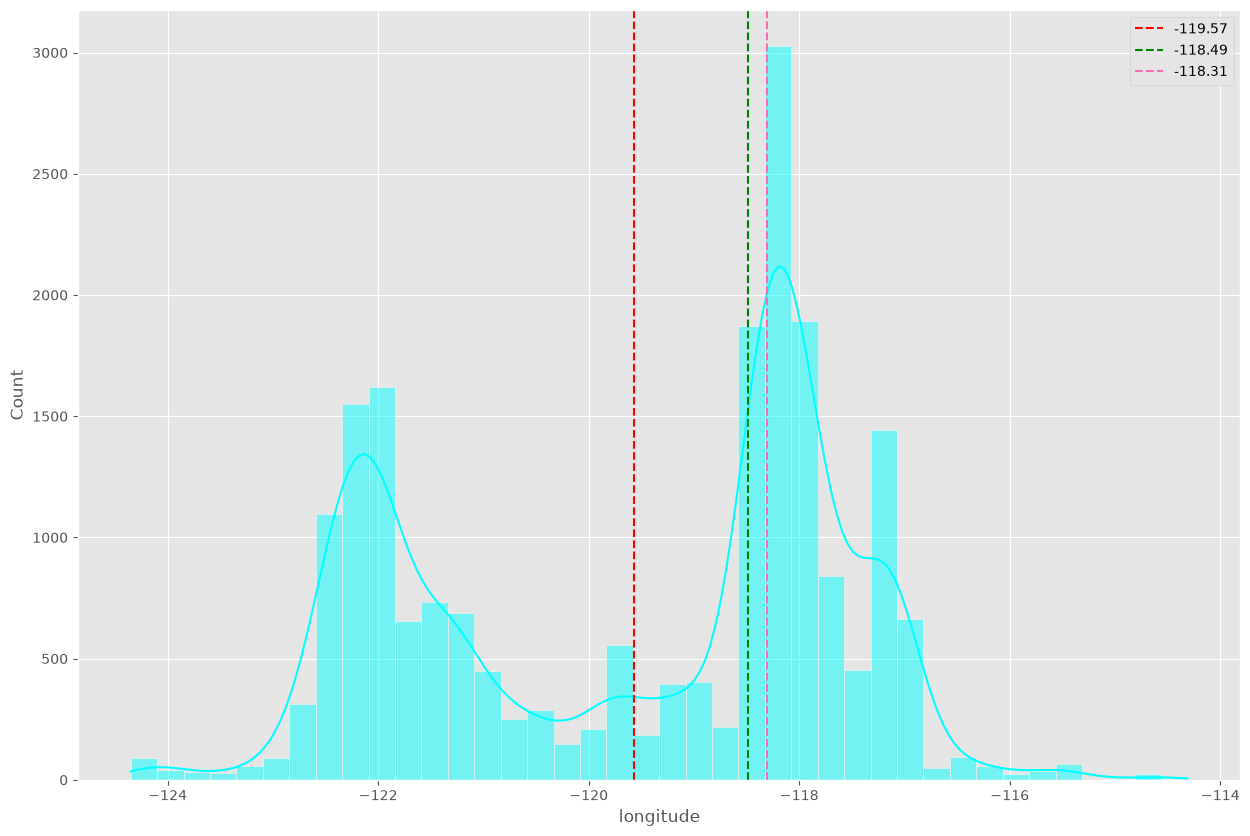



Difference between mean and median :1.08
Distribution is negatively skewed (-ve skewed)
Feature name :  latitude
mean of the latitude : 35.63
median of the latitude : 34.26
mode of the latitude : 34.06


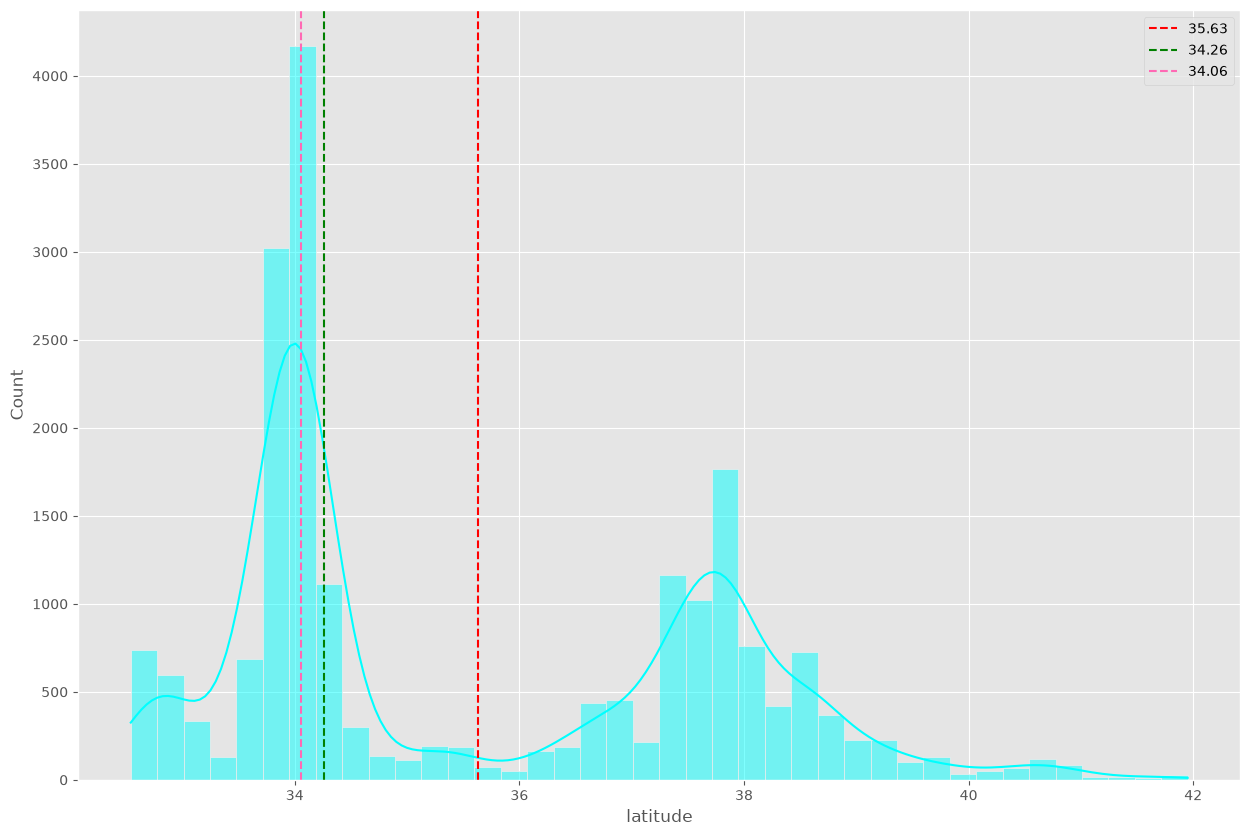



Difference between mean and median :1.37
Distribution is positively skewed (+ve skewed)
Feature name :  housing_median_age
mean of the housing_median_age : 28.64
median of the housing_median_age : 29.00
mode of the housing_median_age : 52.00


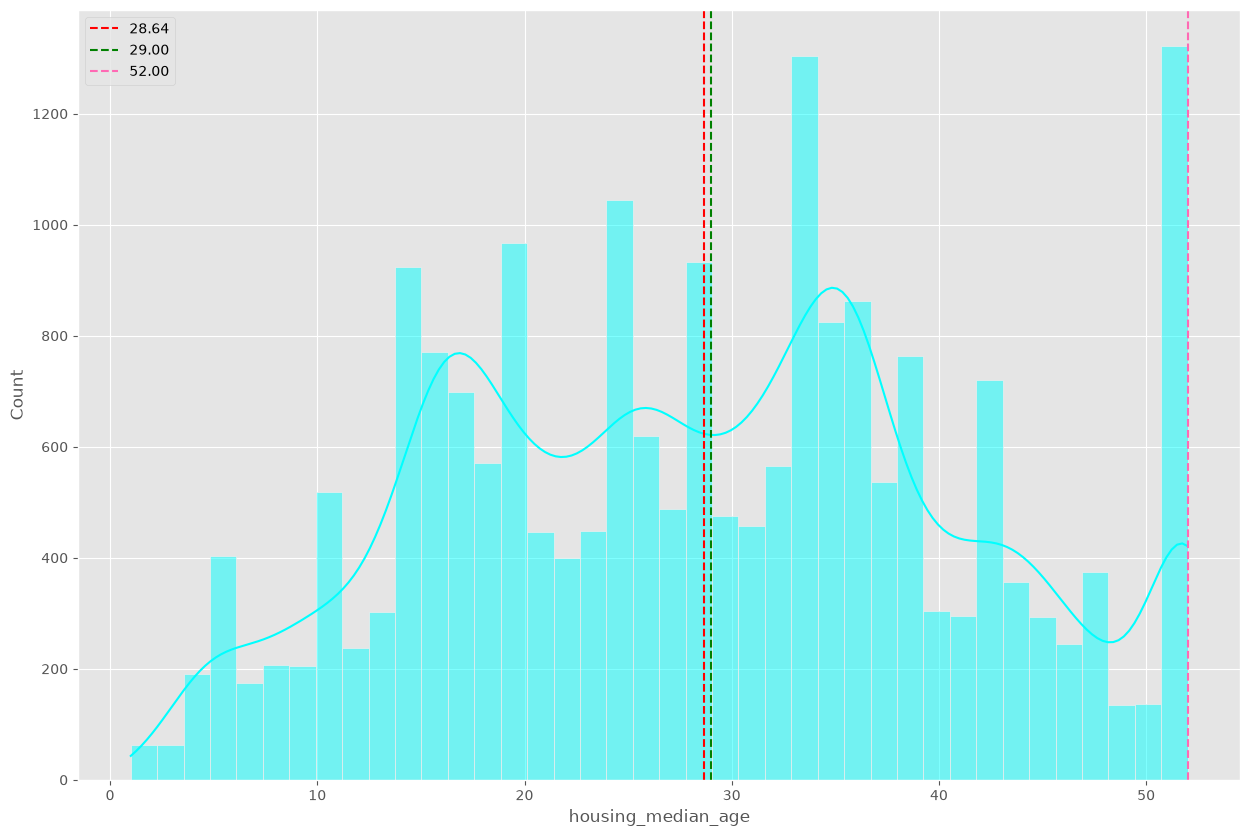



Difference between mean and median :0.36
Distribution is negatively skewed (-ve skewed)
Feature name :  total_rooms
mean of the total_rooms : 2635.76
median of the total_rooms : 2127.00
mode of the total_rooms : 1527.00


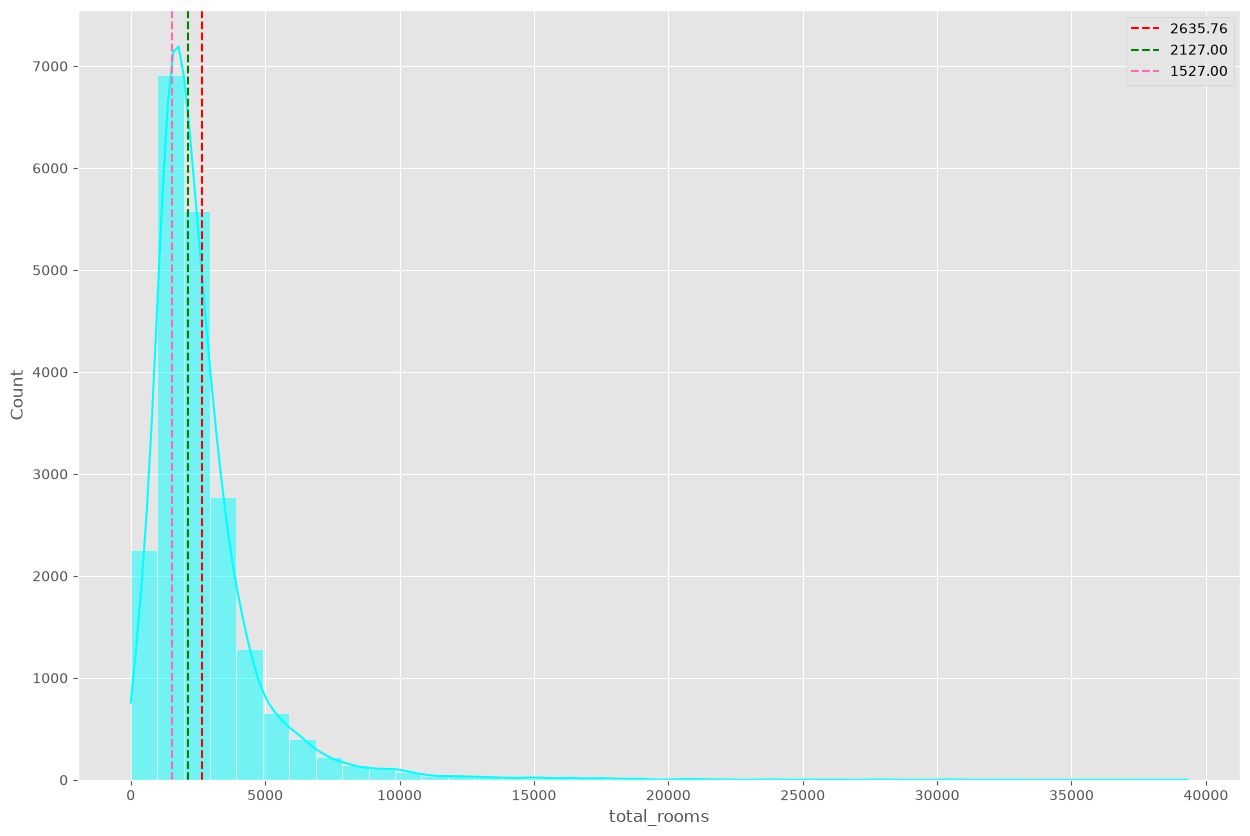



Difference between mean and median :508.76
Distribution is positively skewed (+ve skewed)
Feature name :  total_bedrooms
mean of the total_bedrooms : 537.87
median of the total_bedrooms : 435.00
mode of the total_bedrooms : 280.00


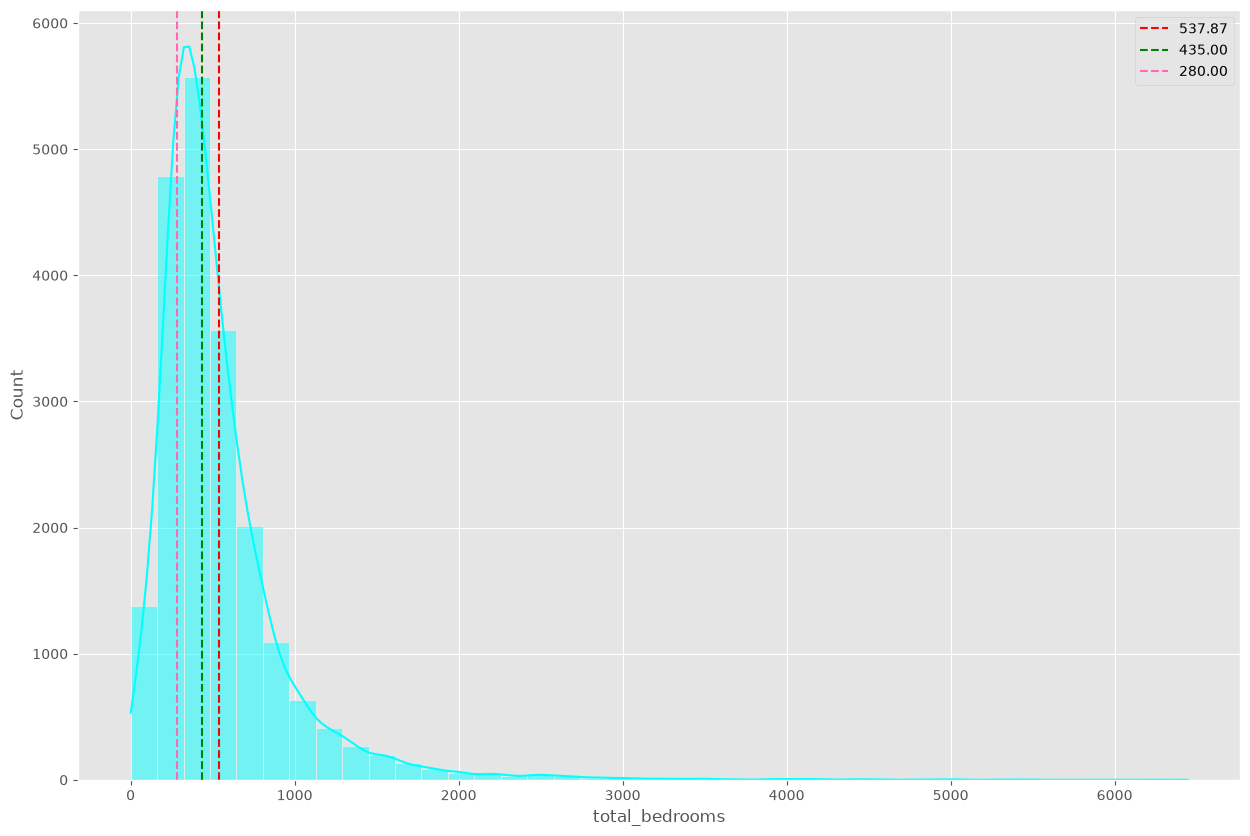



Difference between mean and median :102.87
Distribution is positively skewed (+ve skewed)
Feature name :  population
mean of the population : 1425.48
median of the population : 1166.00
mode of the population : 891.00


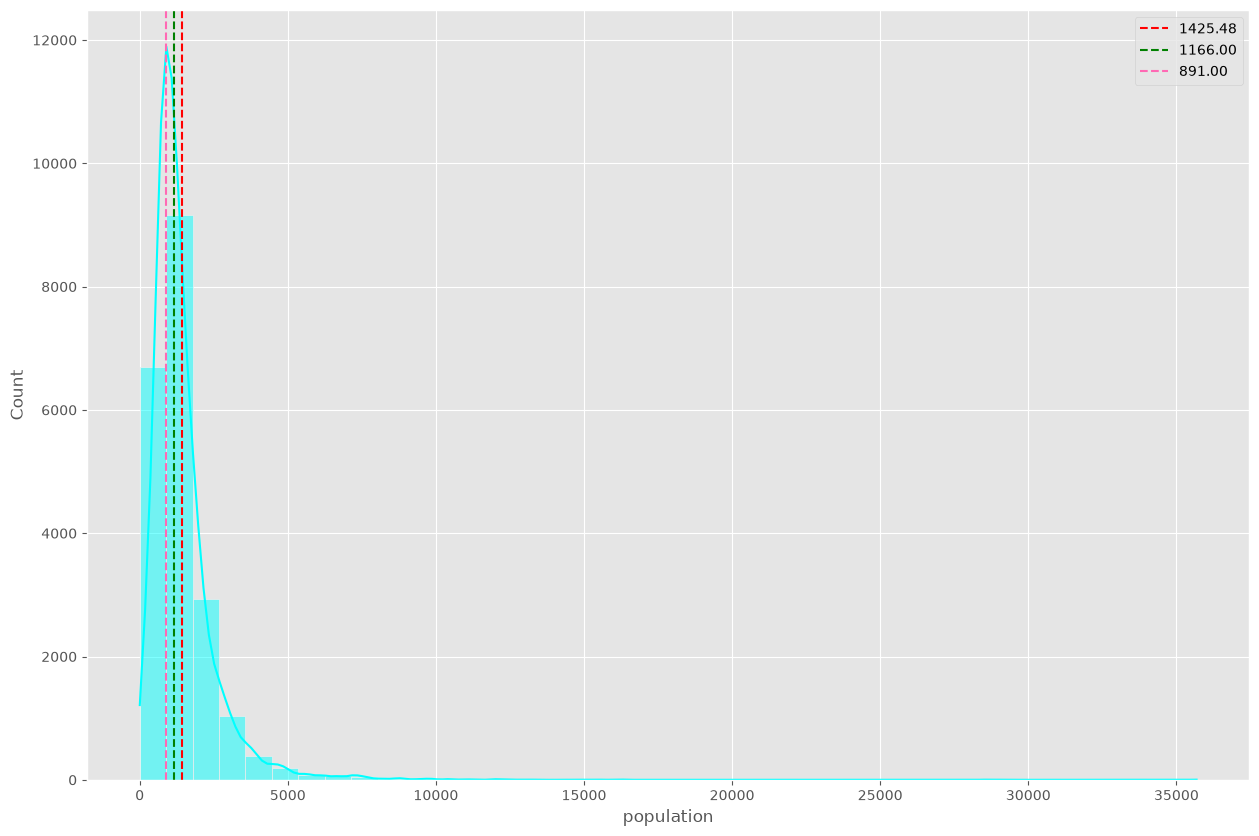



Difference between mean and median :259.48
Distribution is positively skewed (+ve skewed)
Feature name :  households
mean of the households : 499.54
median of the households : 409.00
mode of the households : 306.00


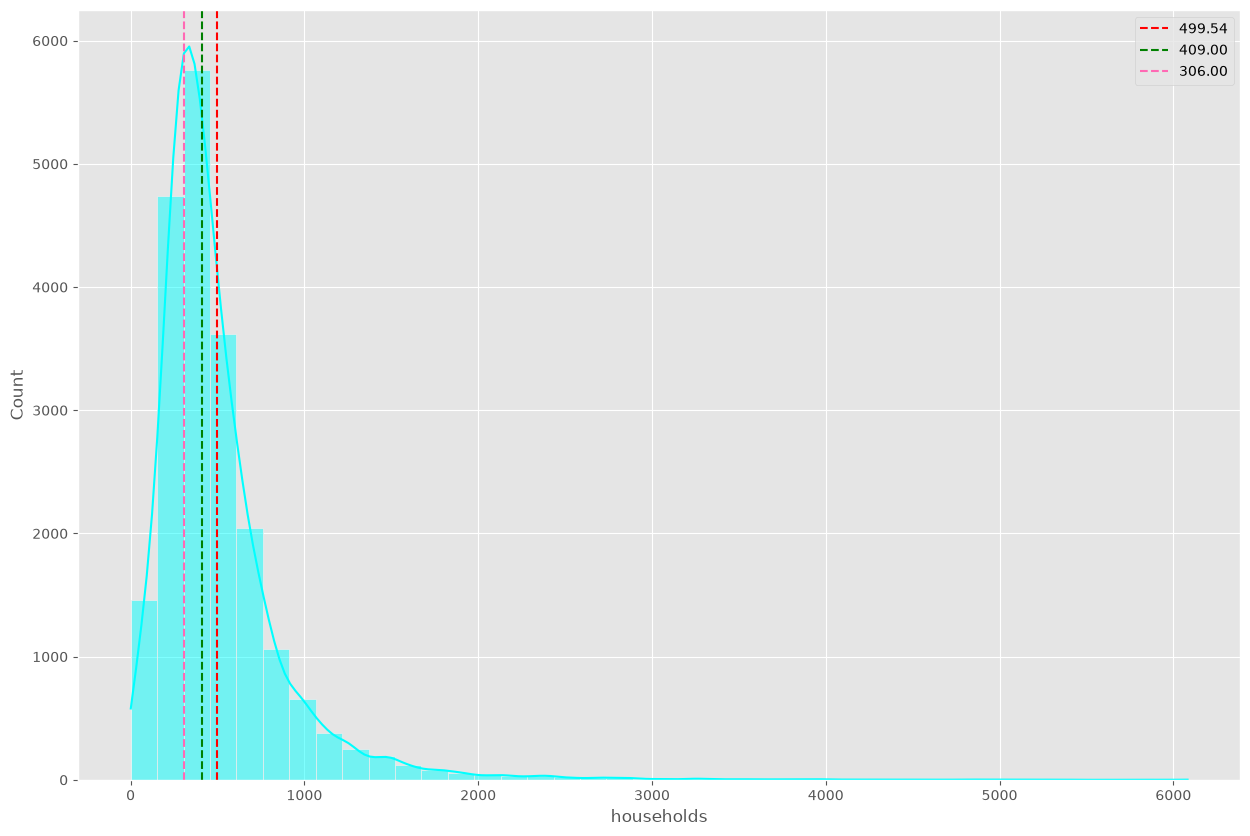



Difference between mean and median :90.54
Distribution is positively skewed (+ve skewed)
Feature name :  median_income
mean of the median_income : 3.87
median of the median_income : 3.53
mode of the median_income : 3.12


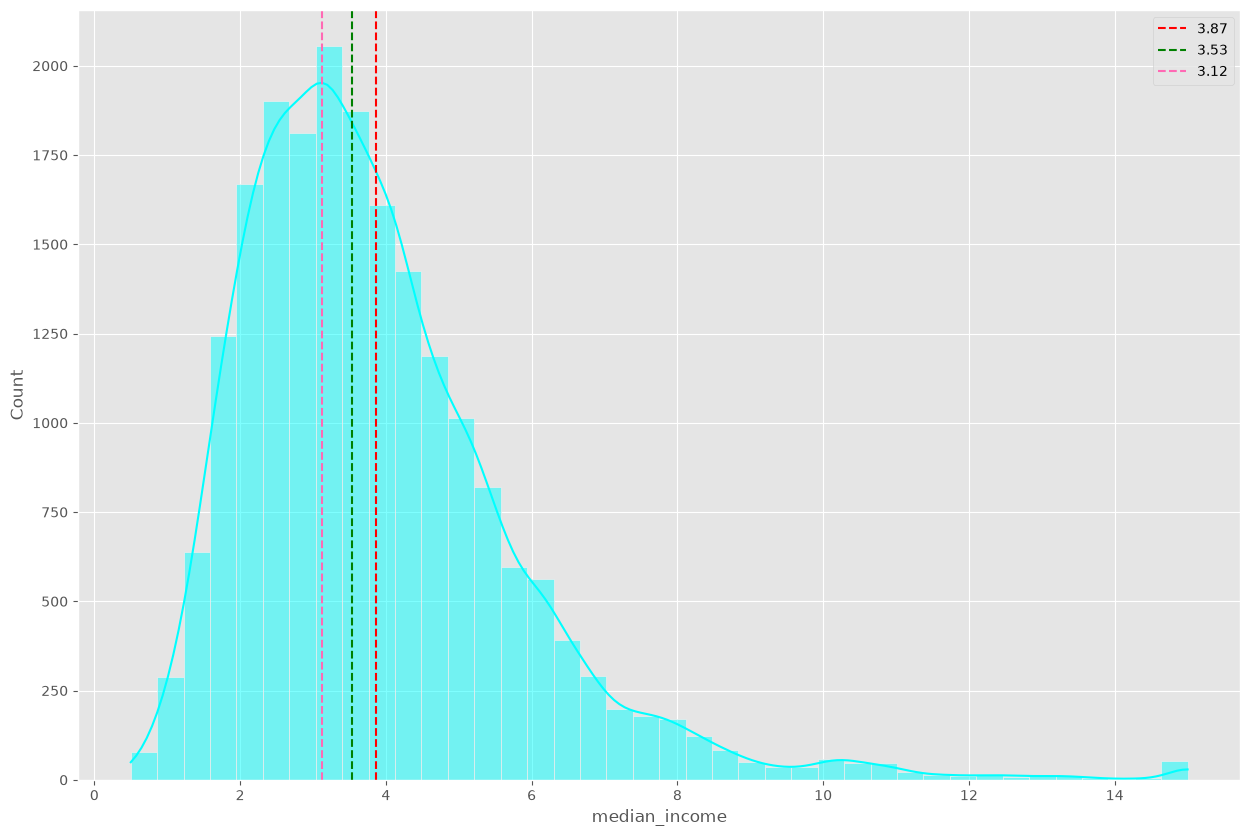



Difference between mean and median :0.34
Distribution is positively skewed (+ve skewed)
Feature name :  median_house_value
mean of the median_house_value : 206855.82
median of the median_house_value : 179700.00
mode of the median_house_value : 500001.00


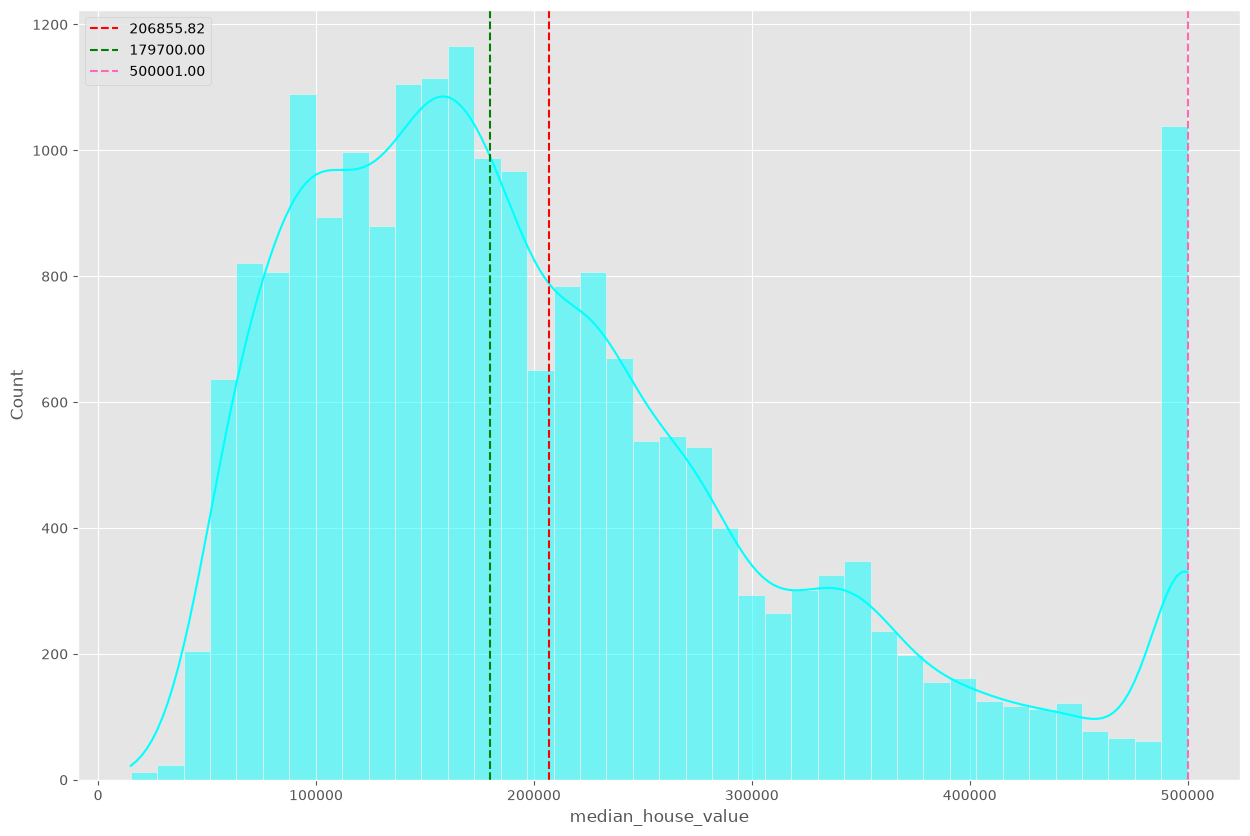



Difference between mean and median :27155.82
Distribution is positively skewed (+ve skewed)


In [7]:
plt.style.use("ggplot")
from scipy import stats
def distribution(data,feature):
    mean=data[feature].mean()
    median=data[feature].median()
    mode=data[feature].mode()[0]
    difference=abs(mean-median)
    print("Feature name : ",feature)
    print(f"mean of the {feature} : {mean:.2f}")
    print(f"median of the {feature} : {median:.2f}")
    print(f"mode of the {feature} : {mode:.2f}")
    plt.figure(figsize=(15,10))
    sns.histplot(data[feature],color="cyan",kde=True,bins=40)
    plt.axvline(mean,color="red",label=f"{mean:.2f}",linestyle="--")
    plt.axvline(median,color="green",label=f"{median:.2f}",linestyle="--")
    plt.axvline(mode,color="hotpink",label=f"{mode:.2f}",linestyle="--")
    plt.legend()

    plt.show()
    print("\n")
    print(f"Difference between mean and median :{difference:.2f}")
    
    if mean > median:
        print("Distribution is positively skewed (+ve skewed)")
    elif mean < median:
        print("Distribution is negatively skewed (-ve skewed)")
    else:
        print("Mean ≈ Median → distribution may be approximately symmetric")   
df_numeric_cols=df.select_dtypes(include=np.number).columns
for col in df_numeric_cols:
    distribution(df,col)

Correlation of features with target variable : 
 median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


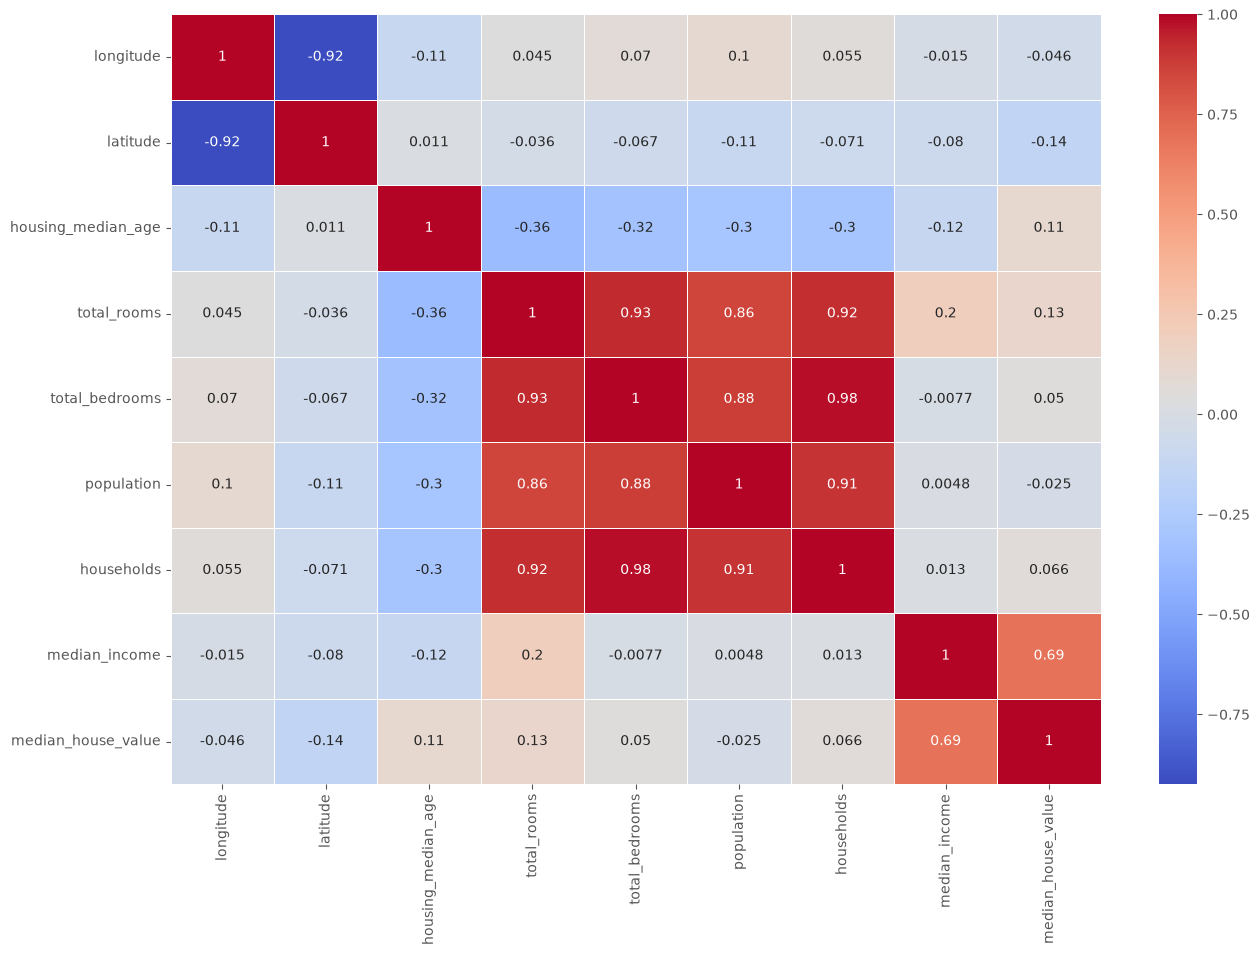

In [8]:
def representing_correltaion_feat(data):
    data_corr=data.select_dtypes(include=np.number).corr()
    data_corr_with_target=data_corr["median_house_value"].sort_values(ascending=False)
    print("Correlation of features with target variable : \n",data_corr_with_target)
    plt.figure(figsize=(15,10))
    sns.heatmap(data_corr,annot=True,cmap="coolwarm",linewidths=0.5)
representing_correltaion_feat(df)


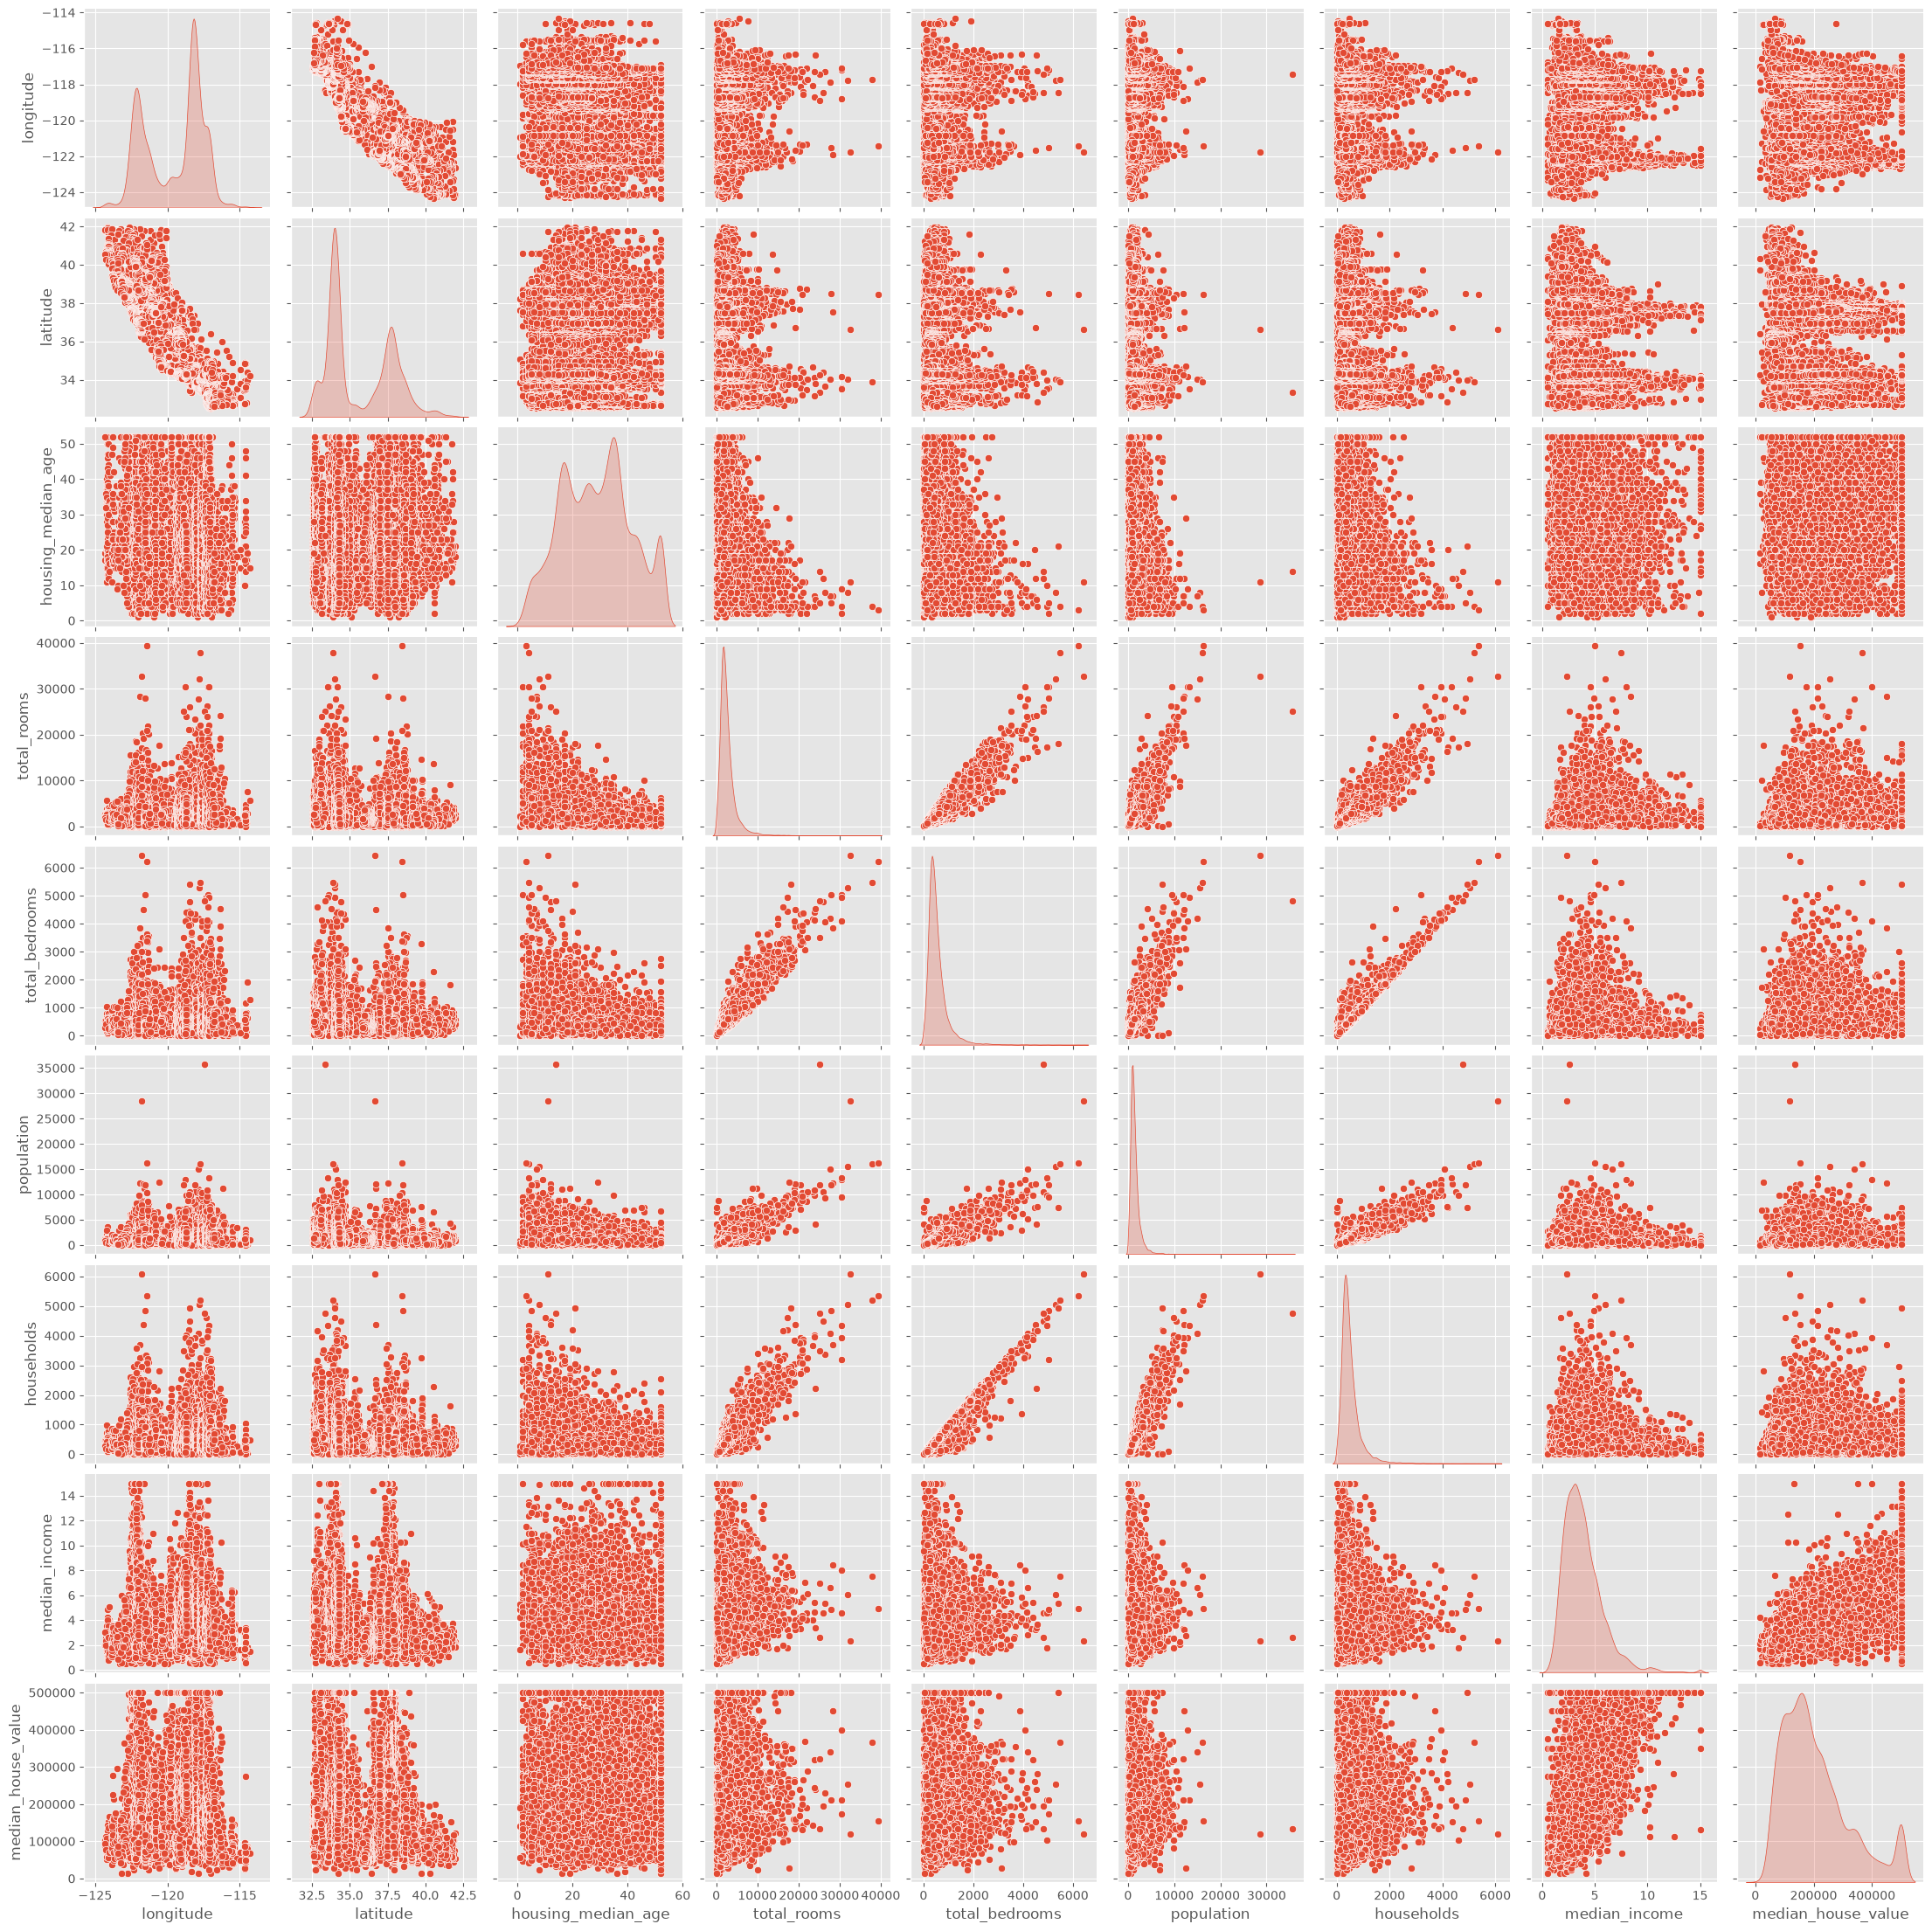

In [9]:
numeric_cols=df.select_dtypes(include=np.number).columns
sns.pairplot(df[numeric_cols],kind="scatter",diag_kind="kde",palette="dark")


Feature name : longitude
Number of outliers in longitude: 0
percentage of outliers in the featurelongitude : 0.00%


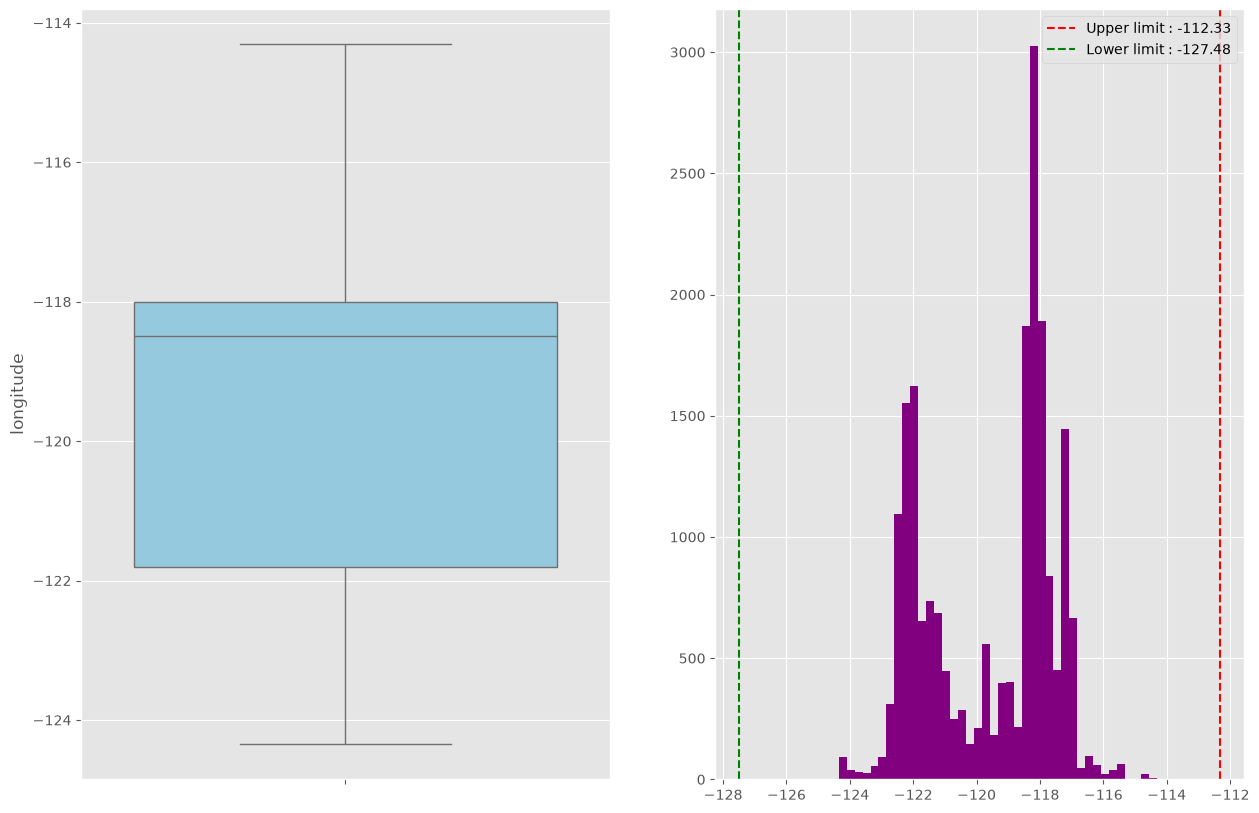

Feature name : latitude
Number of outliers in latitude: 0
percentage of outliers in the featurelatitude : 0.00%


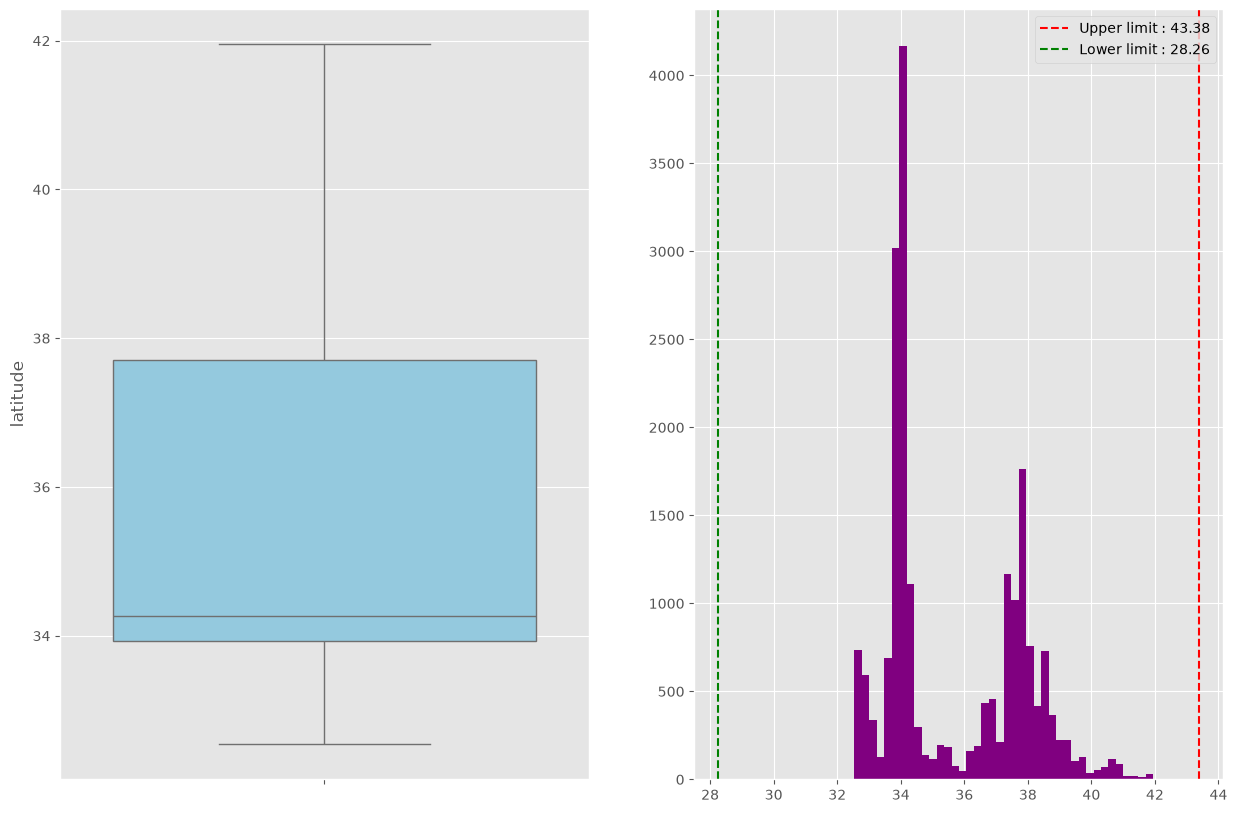

Feature name : housing_median_age
Number of outliers in housing_median_age: 0
percentage of outliers in the featurehousing_median_age : 0.00%


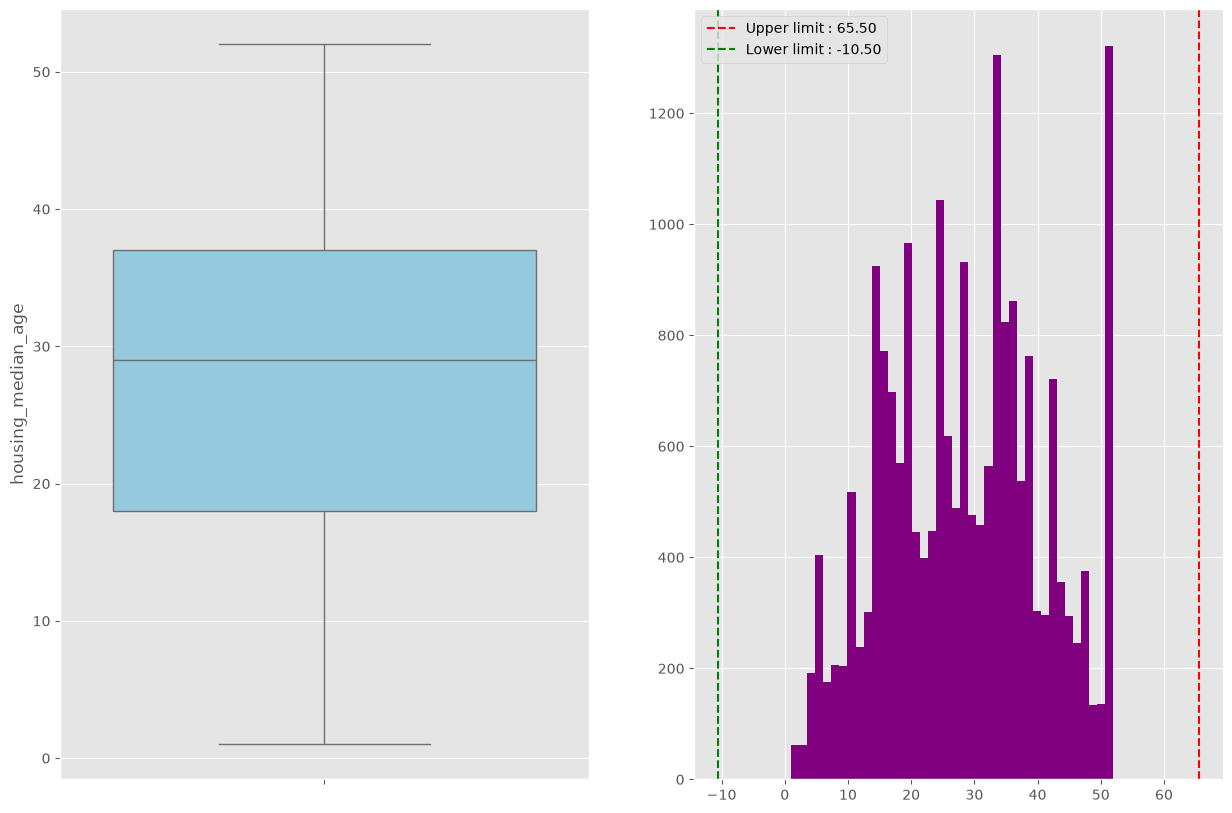

Feature name : total_rooms
Number of outliers in total_rooms: 1287
percentage of outliers in the featuretotal_rooms : 6.24%


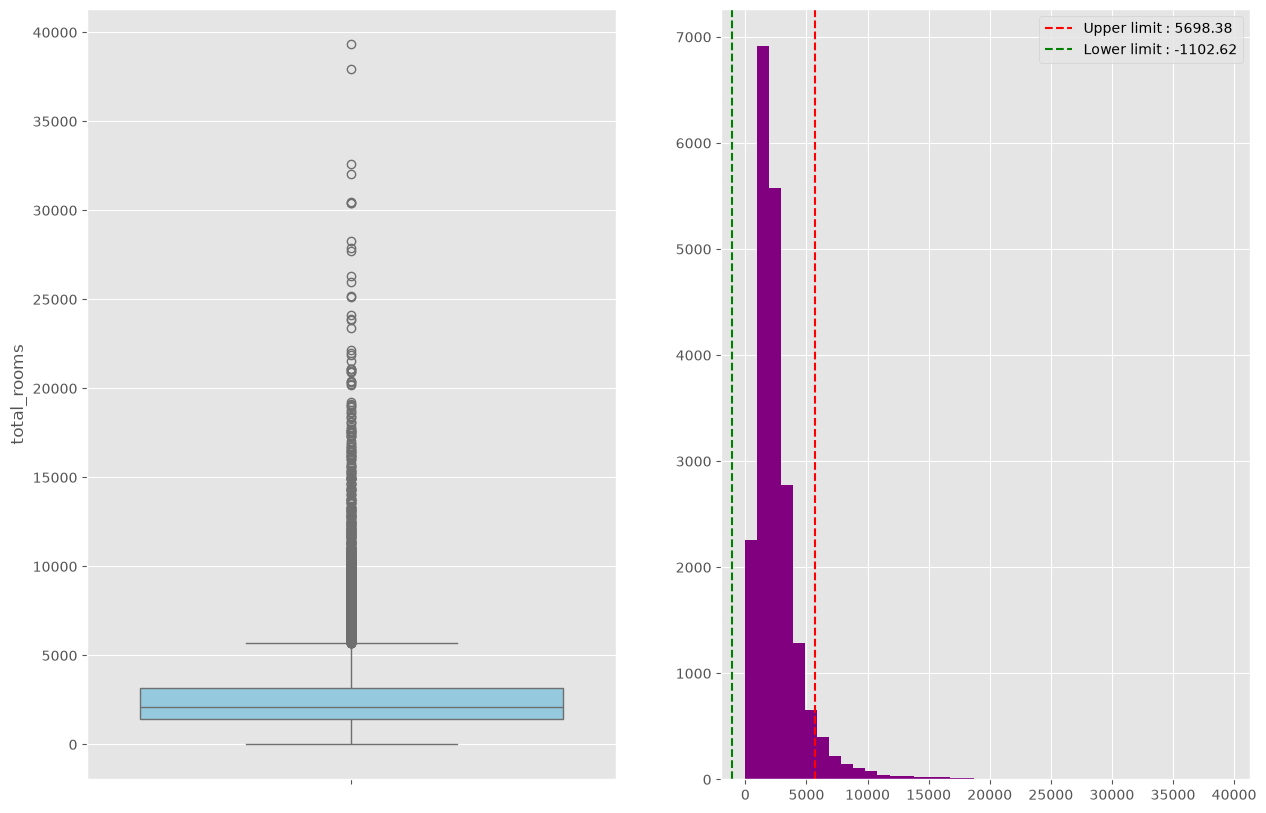

Feature name : total_bedrooms
Number of outliers in total_bedrooms: 1271
percentage of outliers in the featuretotal_bedrooms : 6.16%


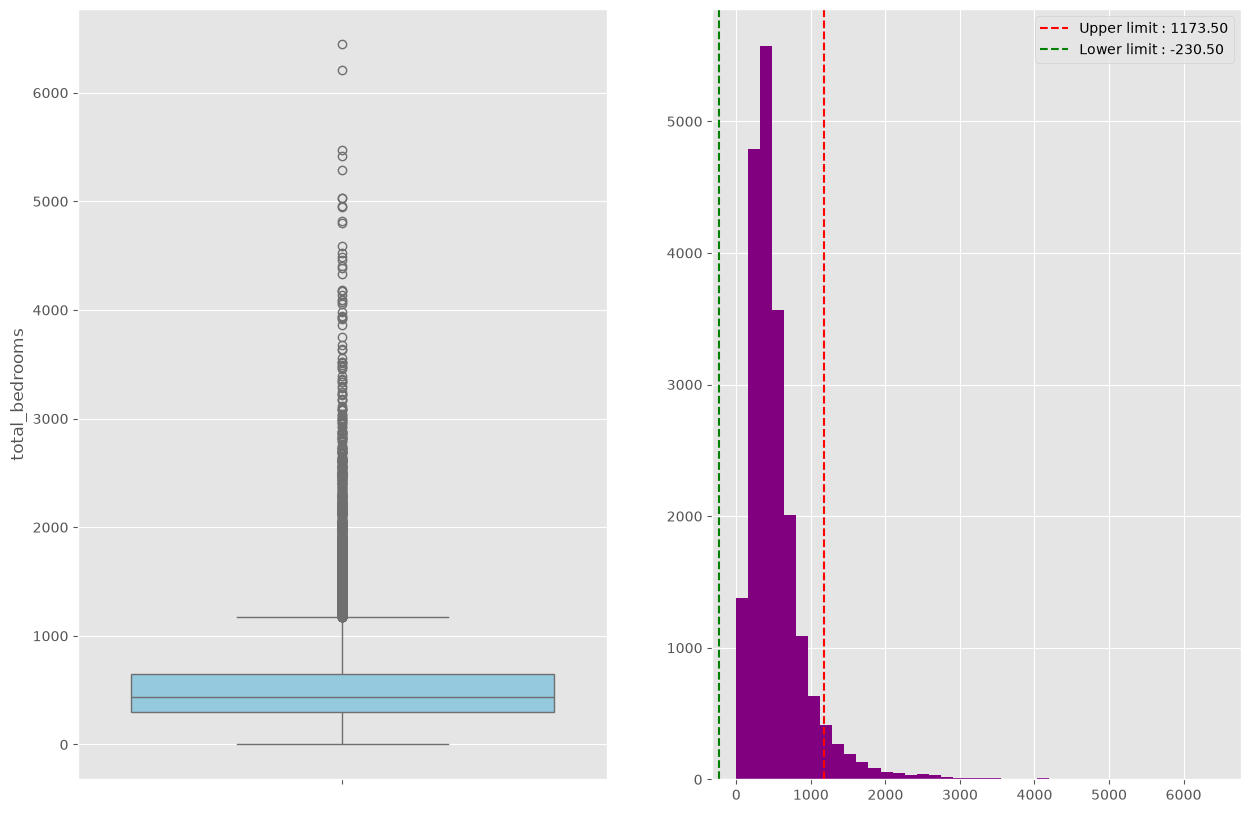

Feature name : population
Number of outliers in population: 1196
percentage of outliers in the featurepopulation : 5.79%


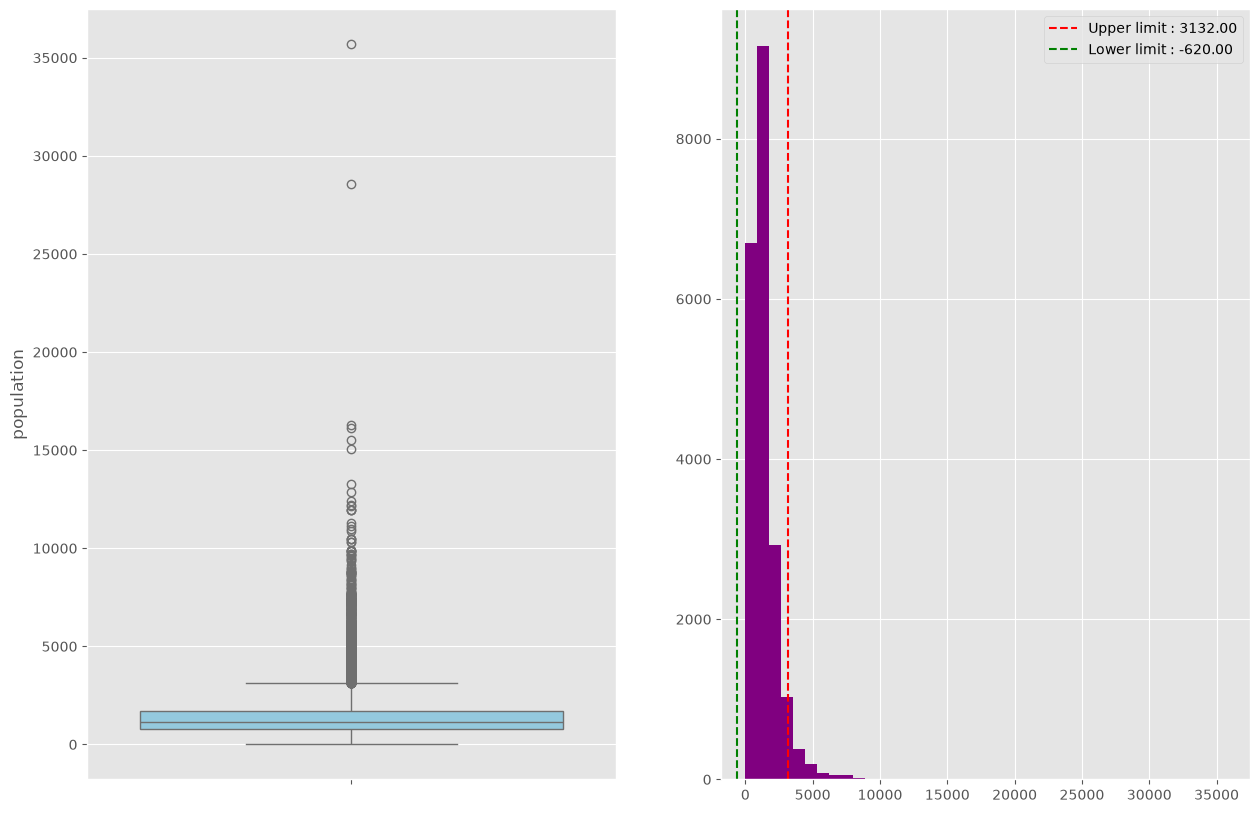

Feature name : households
Number of outliers in households: 1220
percentage of outliers in the featurehouseholds : 5.91%


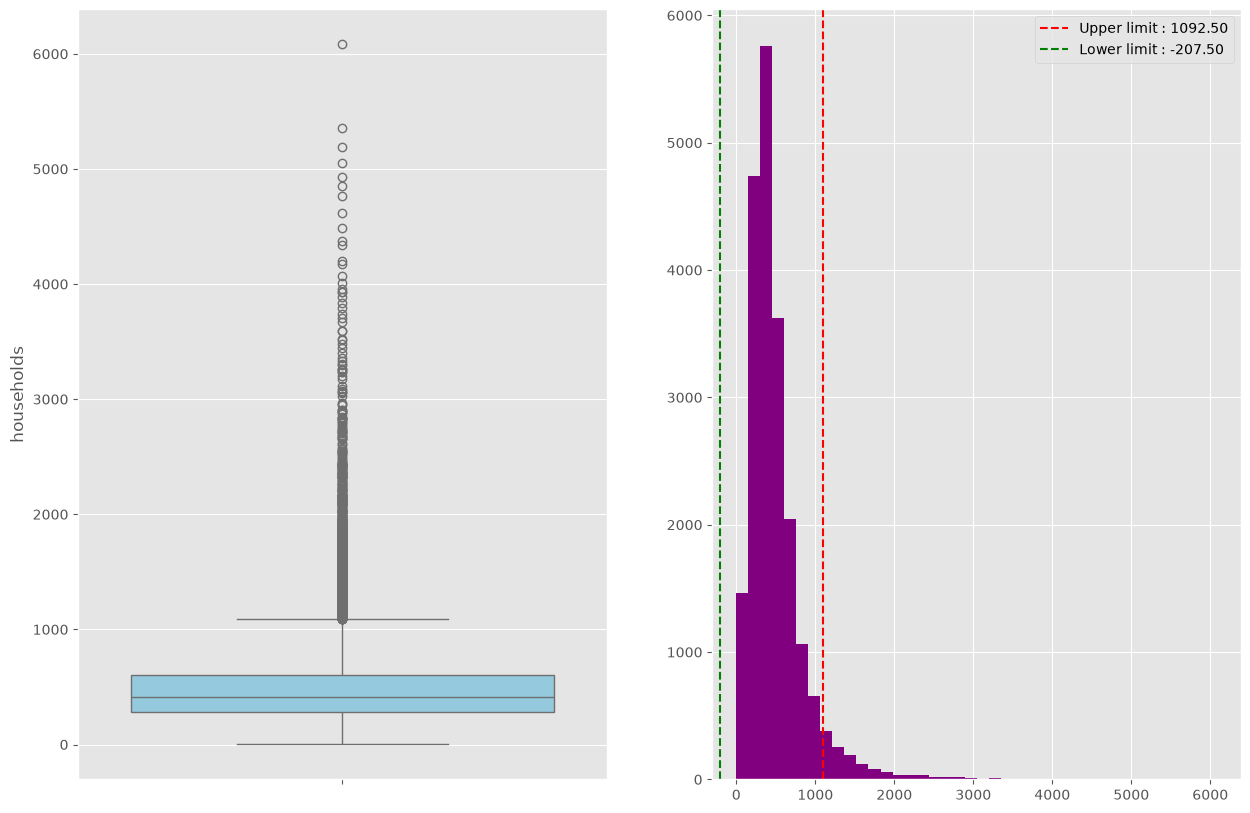

Feature name : median_income
Number of outliers in median_income: 681
percentage of outliers in the featuremedian_income : 3.30%


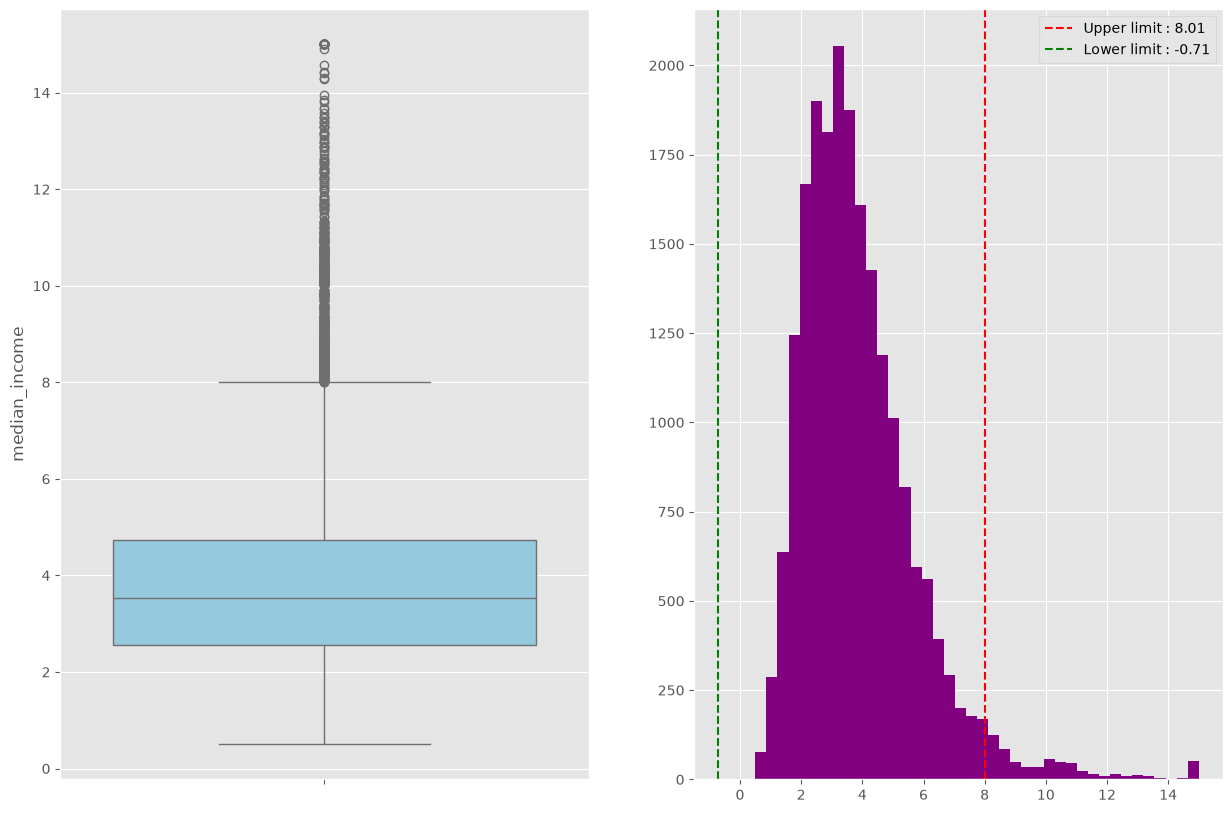

Feature name : median_house_value
Number of outliers in median_house_value: 1071
percentage of outliers in the featuremedian_house_value : 5.19%


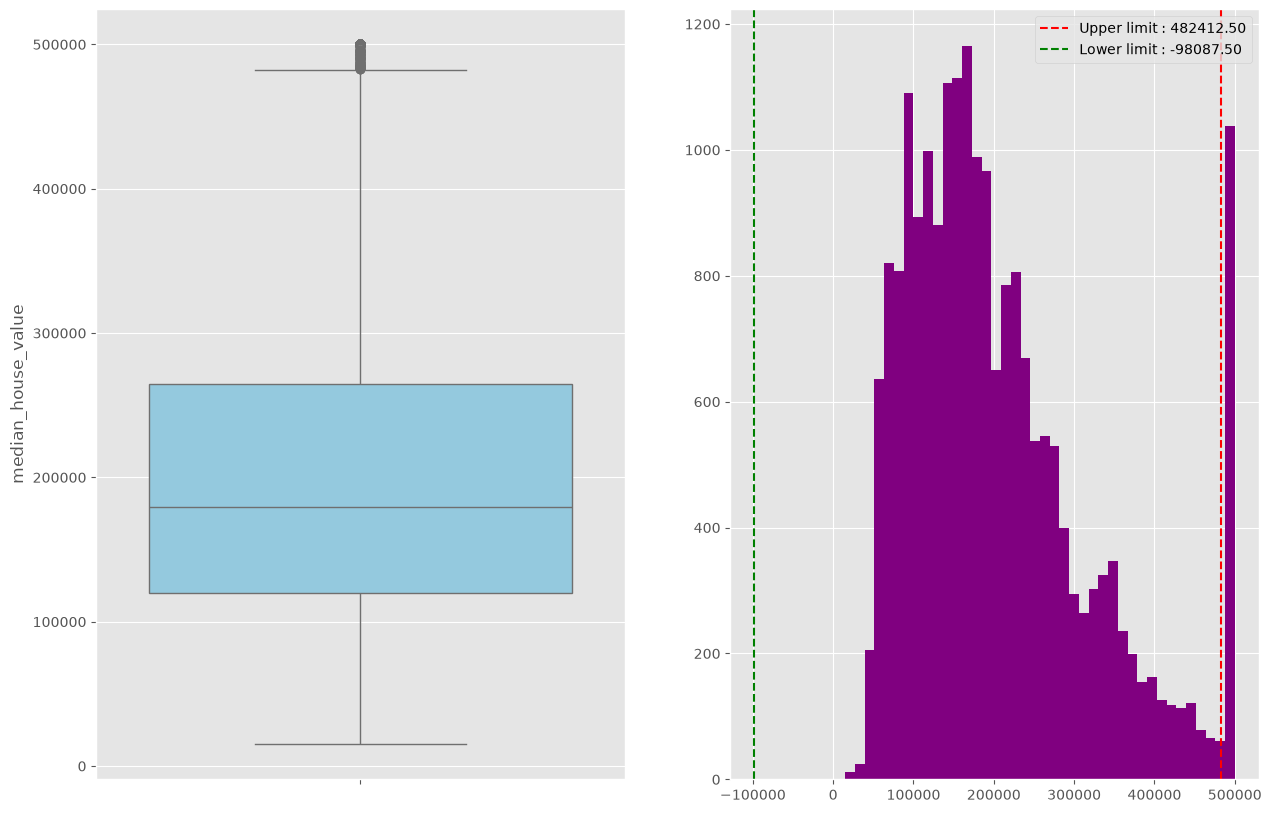

In [10]:
def check_outliers(data,feature):
   Q3=data[feature].quantile(0.75)
   Q1=data[feature].quantile(0.25)
   IQR=Q3-Q1
   lower_limit=Q1-1.5*IQR
   upper_limit=Q3+1.5*IQR
   upper_outliers=(data[feature]>upper_limit)|(data[feature]<lower_limit)
   print(f"Feature name : {feature}")
   print(f"Number of outliers in {feature}: {upper_outliers.sum()}")
   print(F"percentage of outliers in the feature{feature} : {(upper_outliers.sum()/data.shape[0])*100:.2f}%")

   plt.figure(figsize=(15,10))
   plt.subplot(1,2,1)
   sns.boxplot(data[feature],color="skyblue")

   plt.subplot(1,2,2)
   plt.hist(data[feature],color="purple",bins=40)
   plt.axvline(upper_limit,color="red",label=f"Upper limit : {upper_limit:.2f}",linestyle="--")
   plt.axvline(lower_limit,color="green",label=f"Lower limit : {lower_limit:.2f}",linestyle="--")
   plt.legend()
   plt.show()

for col in df_numeric_cols:
   check_outliers(df,col)

Skewness of longitude: -0.2978012079524363
Kurtosis of longitude: -1.3301523662288144
Shapiro-Wilk test statistic: 0.8970, p-value: 0.0000
longitude does not appear to be normally distributed (p-value: 0.0000)


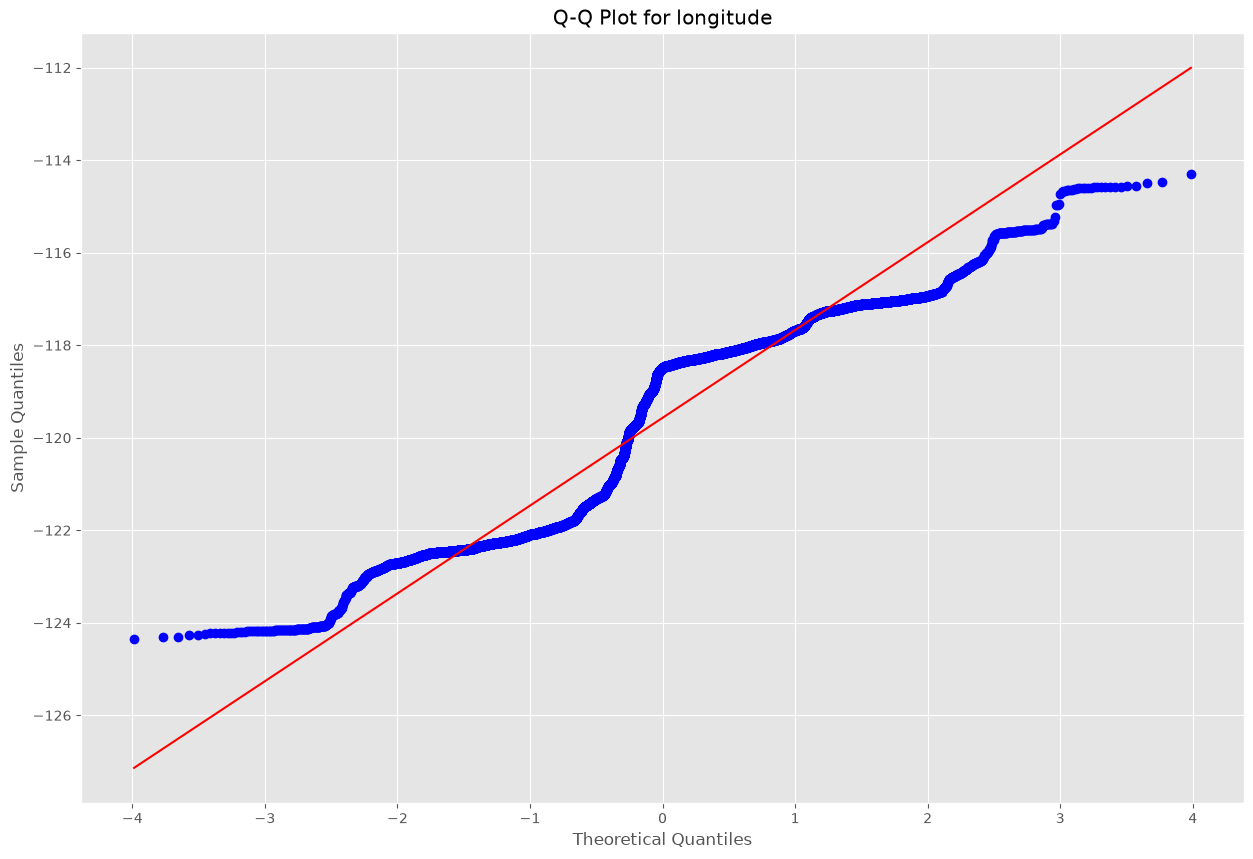

Skewness of latitude: 0.4659530037099799
Kurtosis of latitude: -1.1177597814979463
Shapiro-Wilk test statistic: 0.8771, p-value: 0.0000
latitude does not appear to be normally distributed (p-value: 0.0000)


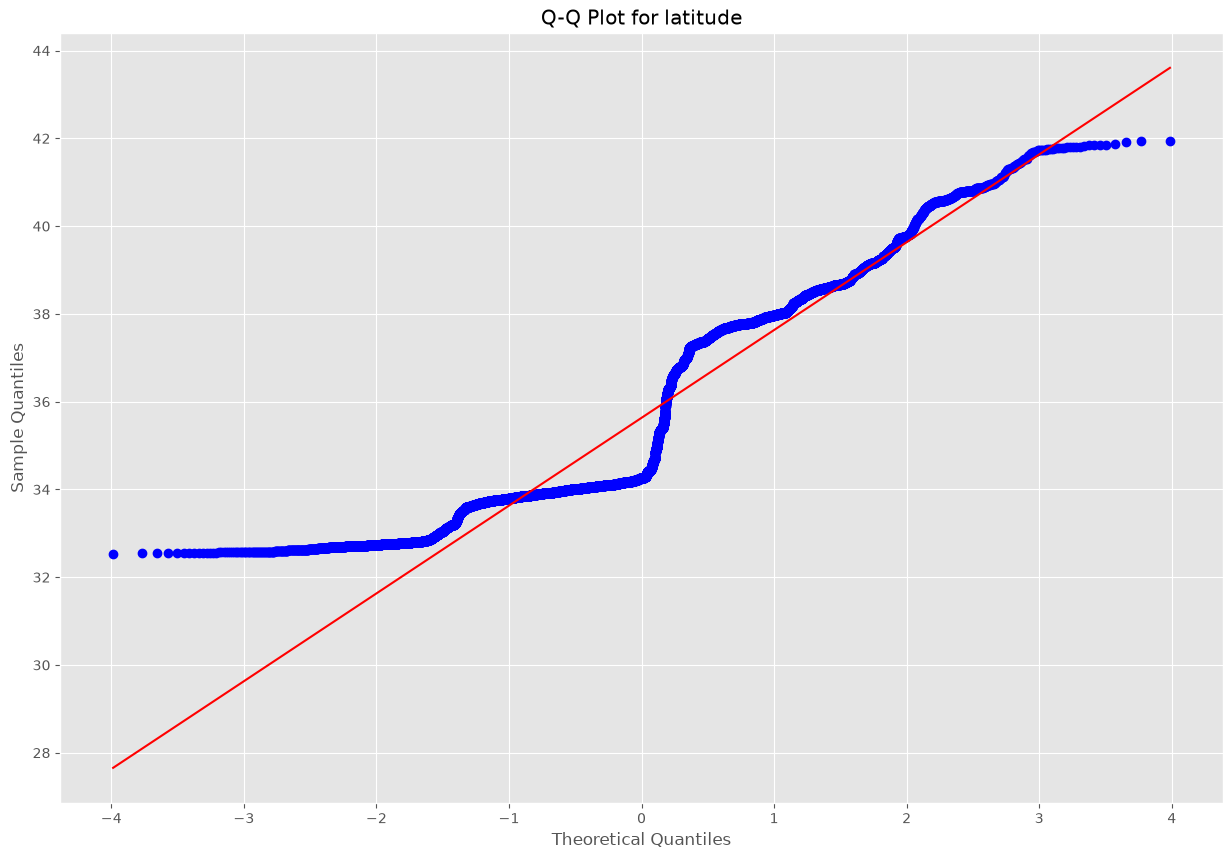

Skewness of housing_median_age: 0.06033063759913685
Kurtosis of housing_median_age: -0.800628853586641
Shapiro-Wilk test statistic: 0.9782, p-value: 0.0000
housing_median_age does not appear to be normally distributed (p-value: 0.0000)


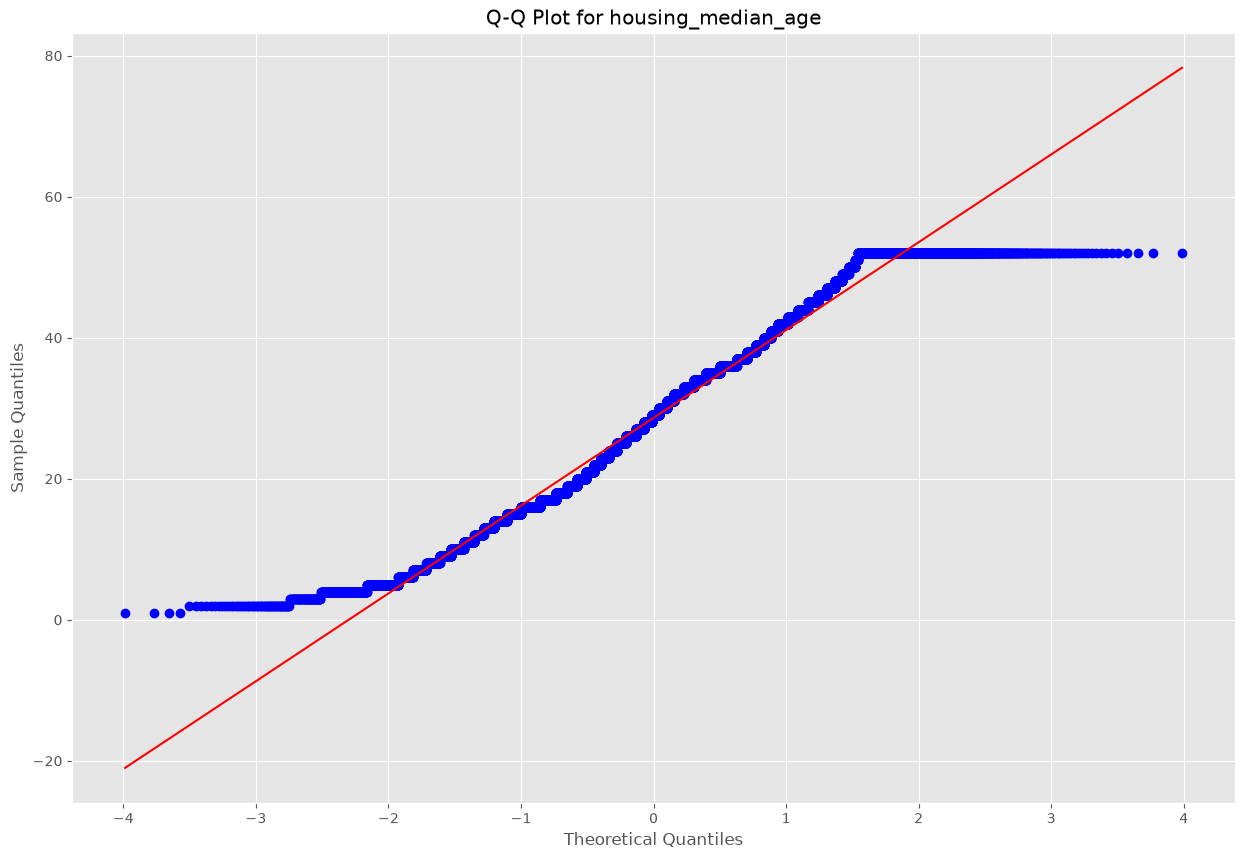

Skewness of total_rooms: 4.147343450632158
Kurtosis of total_rooms: 32.630926999208725
Shapiro-Wilk test statistic: 0.6952, p-value: 0.0000
total_rooms does not appear to be normally distributed (p-value: 0.0000)


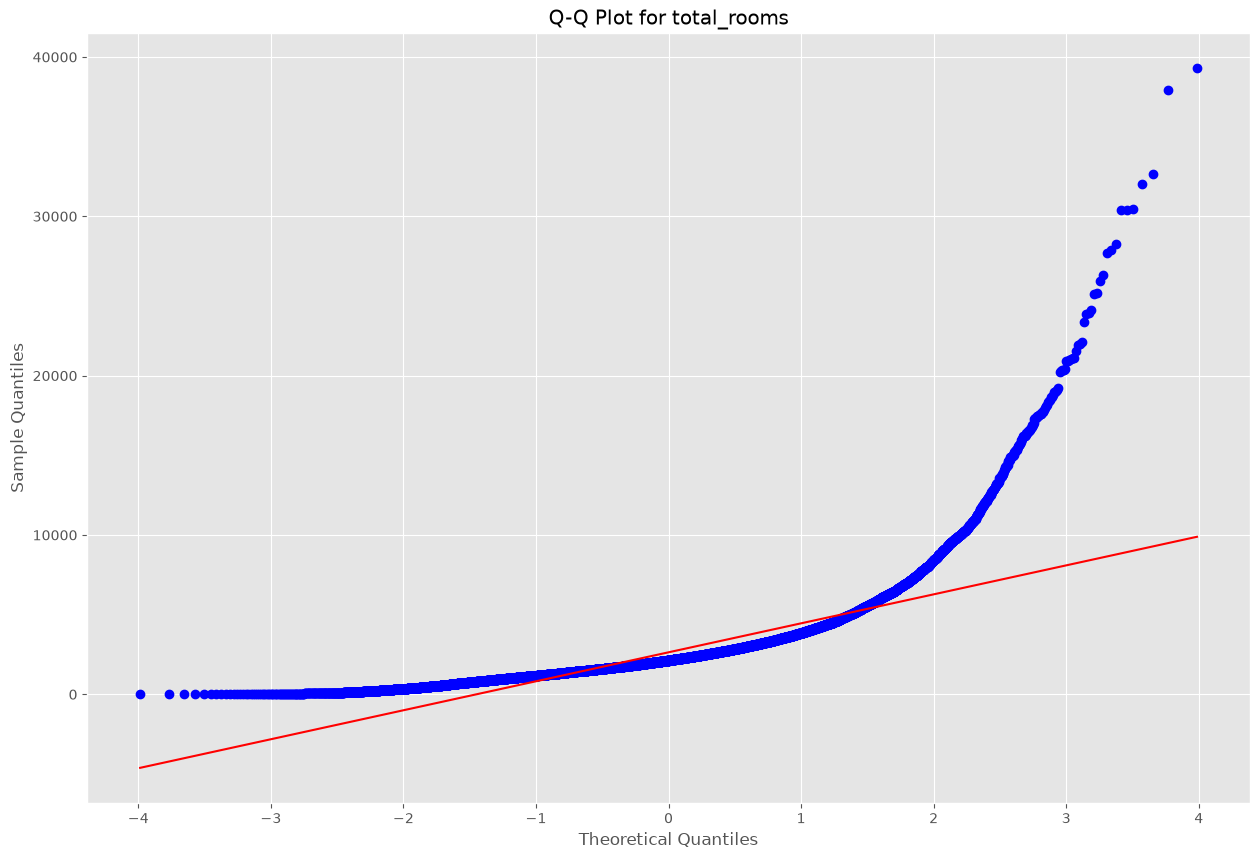

Skewness of total_bedrooms: 3.459546331523342
Kurtosis of total_bedrooms: 21.985575060645207
Shapiro-Wilk test statistic: nan, p-value: nan
total_bedrooms does not appear to be normally distributed (p-value: nan)


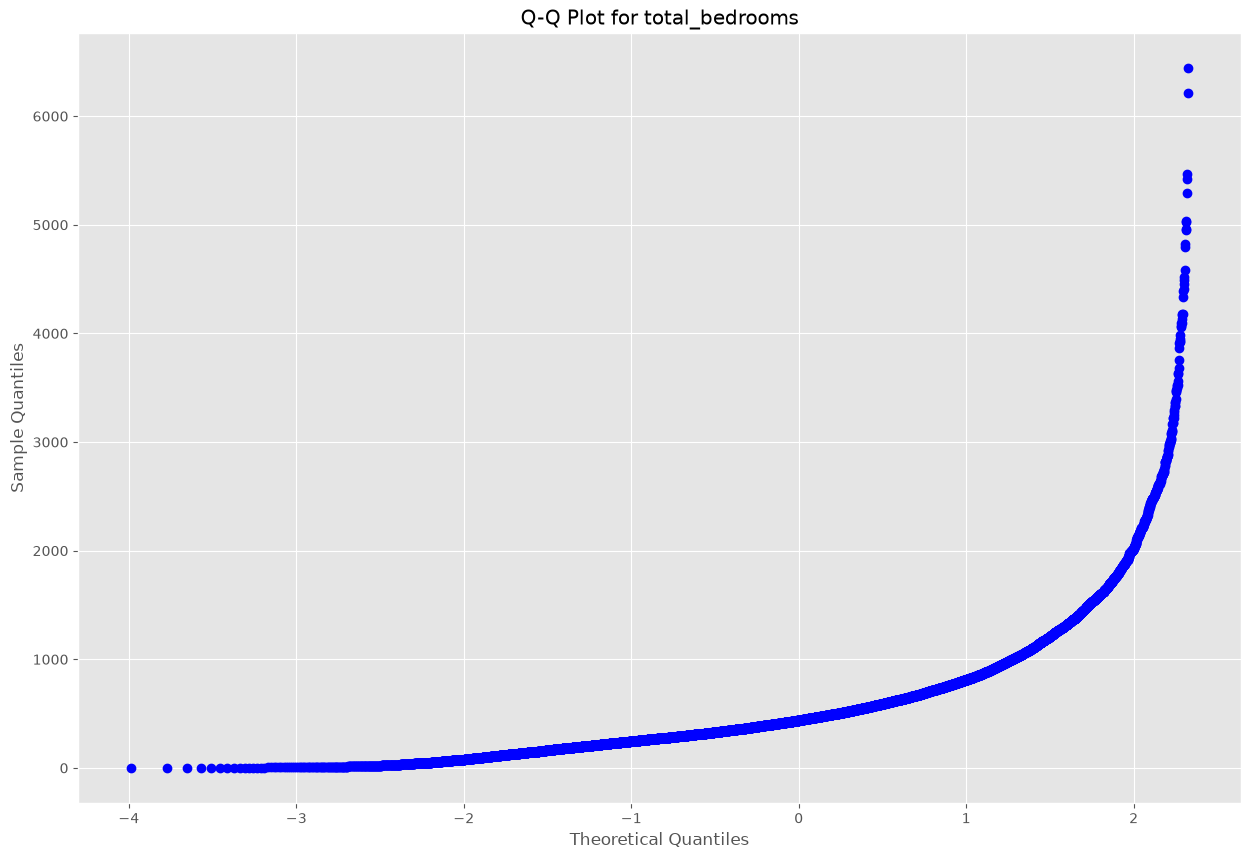

Skewness of population: 4.935858226727124
Kurtosis of population: 73.55311639416514
Shapiro-Wilk test statistic: 0.7133, p-value: 0.0000
population does not appear to be normally distributed (p-value: 0.0000)


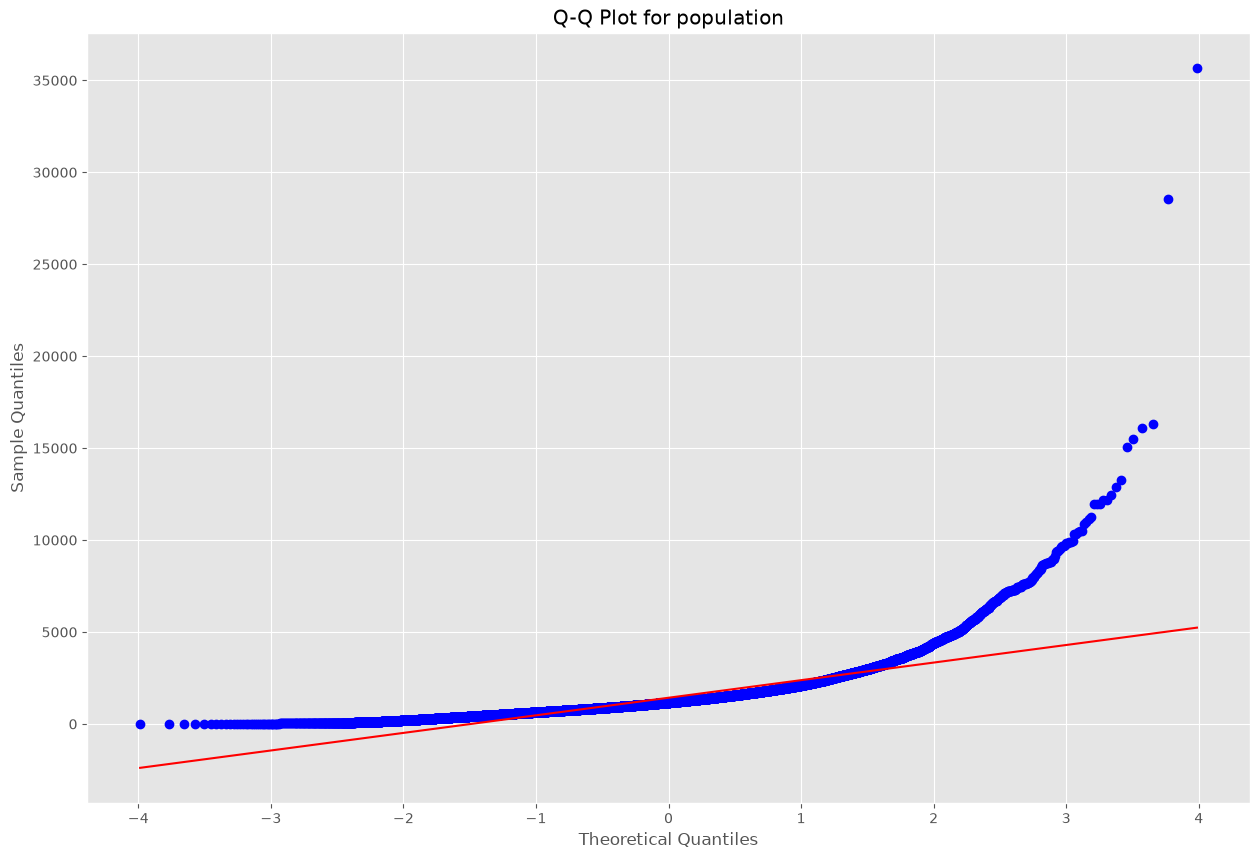

Skewness of households: 3.4104377116671474
Kurtosis of households: 22.057988059658797
Shapiro-Wilk test statistic: 0.7456, p-value: 0.0000
households does not appear to be normally distributed (p-value: 0.0000)


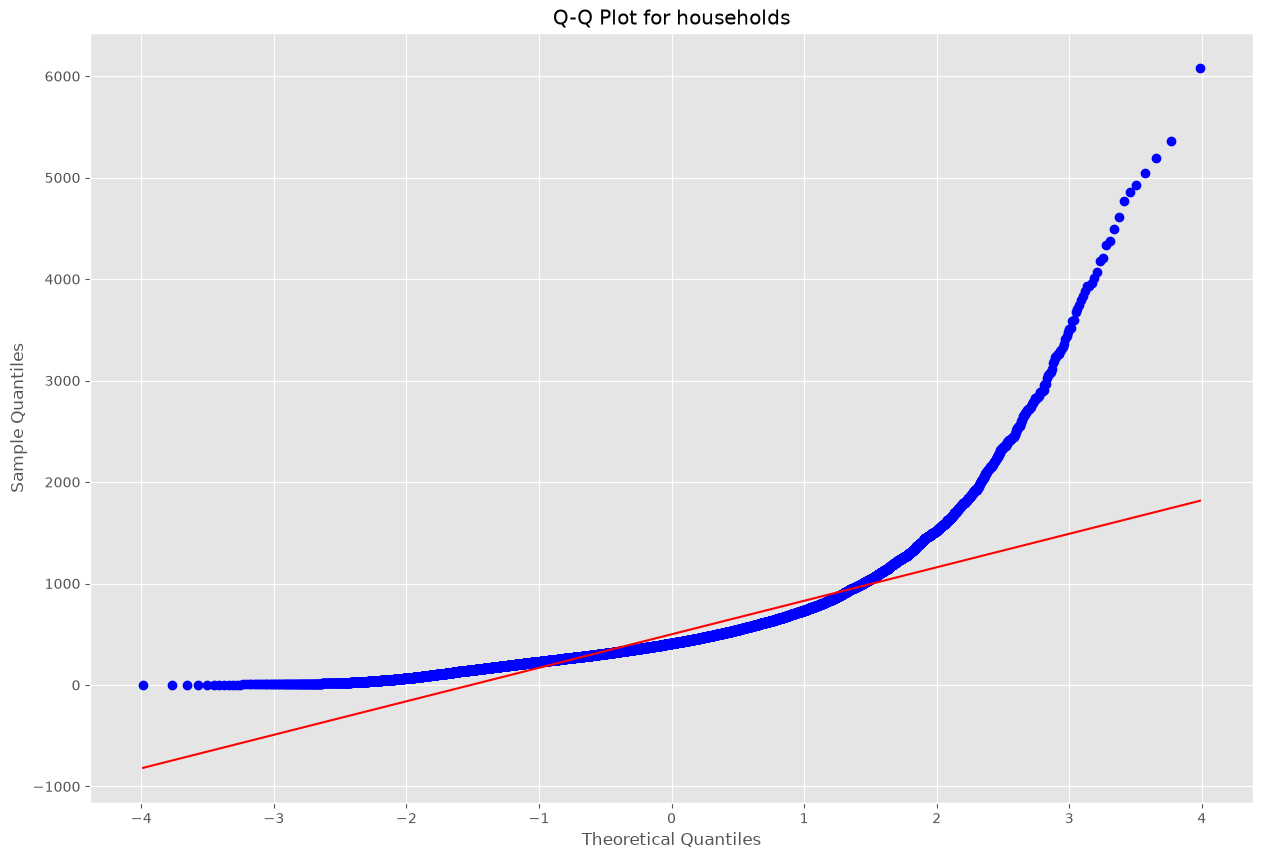

Skewness of median_income: 1.6466567021344465
Kurtosis of median_income: 4.952524101991511
Shapiro-Wilk test statistic: 0.8932, p-value: 0.0000
median_income does not appear to be normally distributed (p-value: 0.0000)


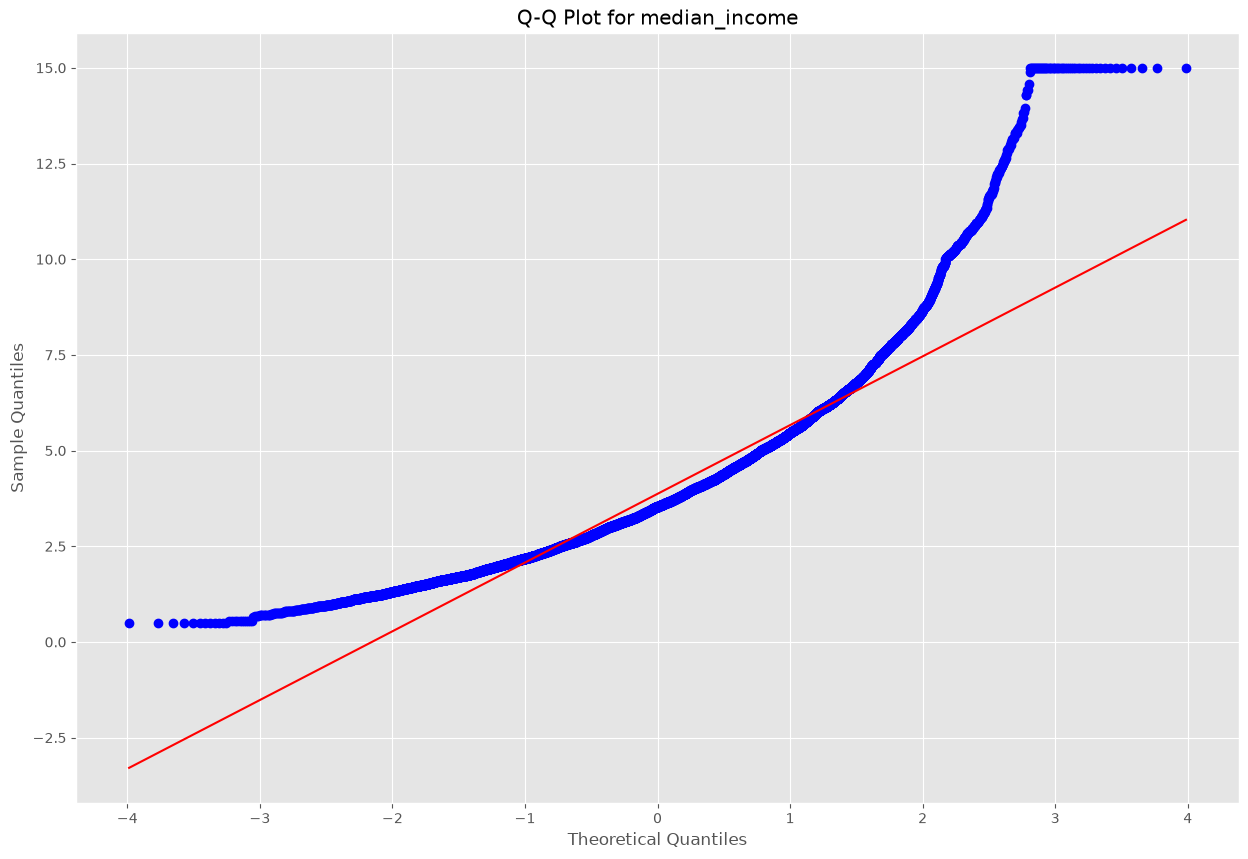

Skewness of median_house_value: 0.9777632739098342
Kurtosis of median_house_value: 0.3278702429465876
Shapiro-Wilk test statistic: 0.9123, p-value: 0.0000
median_house_value does not appear to be normally distributed (p-value: 0.0000)


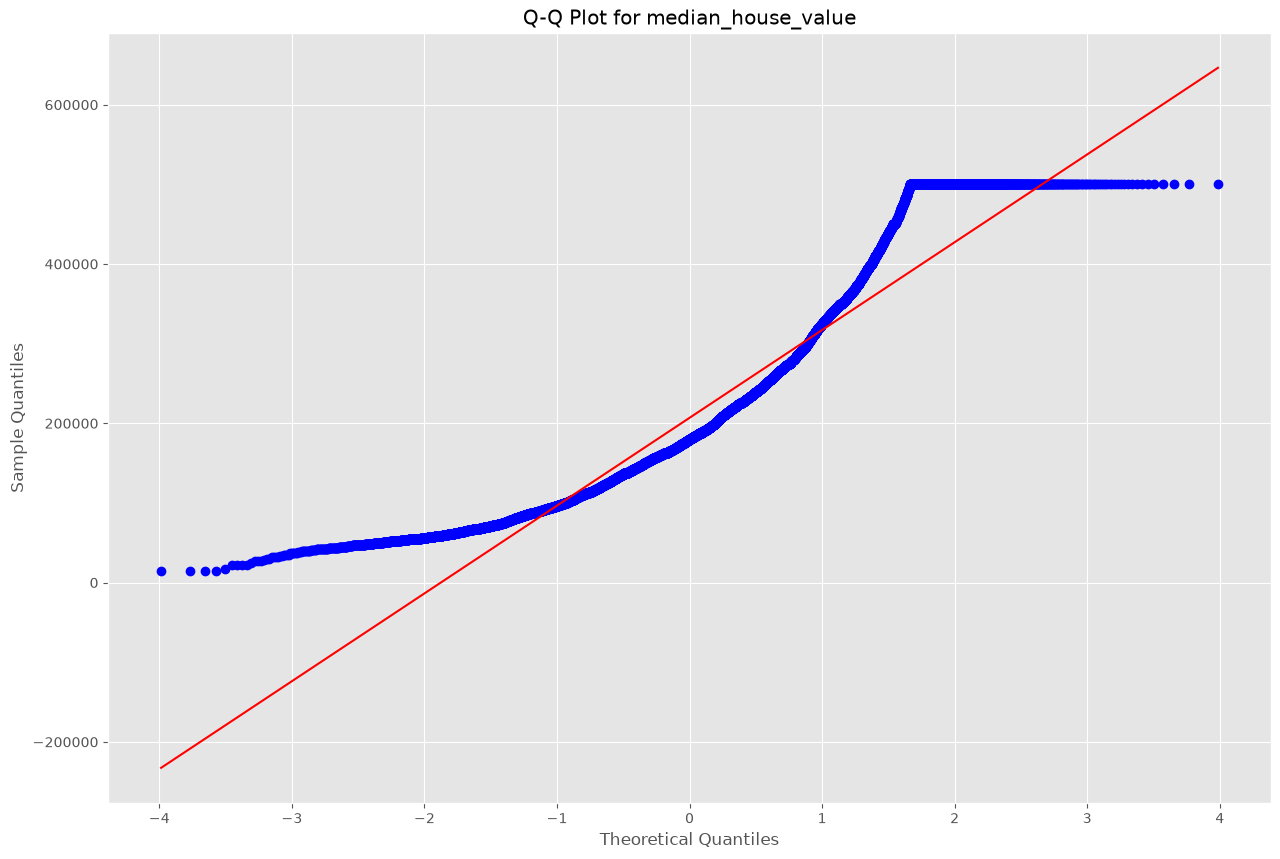

In [11]:
from scipy import stats
def check_normality(data,feature):
 skewness=data[feature].skew()
 kurtosis=data[feature].kurtosis()
 print(f"Skewness of {feature}: {skewness}")
 print(f"Kurtosis of {feature}: {kurtosis}")
 stat, p_value = stats.shapiro(data[feature])
 print(f"Shapiro-Wilk test statistic: {stat:.4f}, p-value: {p_value:.4f}")
 if p_value > 0.05:
  print(f"{feature} appears to be normally distributed (p-value: {p_value:.4f})")
 else:
  print(f"{feature} does not appear to be normally distributed (p-value: {p_value:.4f})")
 plt.figure(figsize=(15,10))
 stats.probplot(data[feature], dist="norm", plot=plt)
 plt.title(f"Q-Q Plot for {feature}")
 plt.xlabel("Theoretical Quantiles")
 plt.ylabel("Sample Quantiles")
 plt.show()

for col in df_numeric_cols:
    check_normality(df, col)

In [12]:
def measure_of_dispersion(data,features):
    range=data[features].max()-data[features].min()
    var=data [features].var()  
    std=data[features].std()     
    mean=data[features].mean()
    coff_of_var=(std/mean)*100

    print(f"feature : {features}")
    print(f"range of the feature : {range:.2f}")
    print(f"variance of the feature : {var:.2f}")
    print(f"standard deviation of the feature : {std:.2f}")
    print(f"coefficient of variation of the feature : {coff_of_var:.2f}%")
    print("\n")


for col in df_numeric_cols[:4]:
    measure_of_dispersion(df,col)

feature : longitude
range of the feature : 10.04
variance of the feature : 4.01
standard deviation of the feature : 2.00
coefficient of variation of the feature : -1.68%


feature : latitude
range of the feature : 9.41
variance of the feature : 4.56
standard deviation of the feature : 2.14
coefficient of variation of the feature : 5.99%


feature : housing_median_age
range of the feature : 51.00
variance of the feature : 158.40
standard deviation of the feature : 12.59
coefficient of variation of the feature : 43.94%


feature : total_rooms
range of the feature : 39318.00
variance of the feature : 4759445.11
standard deviation of the feature : 2181.62
coefficient of variation of the feature : 82.77%




In [13]:
def measure_of_dispersion(data,features):
    range=data[features].max()-data[features].min()
    var=data [features].var()  
    std=data[features].std()     
    mean=data[features].mean()
    coff_of_var=(std/mean)*100

    print(f"feature : {features}")
    print(f"range of the feature : {range:.2f}")
    print(f"variance of the feature : {var:.2f}")
    print(f"standard deviation of the feature : {std:.2f}")
    print(f"coefficient of variation of the feature : {coff_of_var:.2f}%")
    print("\n")


for col in df_numeric_cols[4:8]:
    measure_of_dispersion(df,col)

feature : total_bedrooms
range of the feature : 6444.00
variance of the feature : 177565.38
standard deviation of the feature : 421.39
coefficient of variation of the feature : 78.34%


feature : population
range of the feature : 35679.00
variance of the feature : 1282470.46
standard deviation of the feature : 1132.46
coefficient of variation of the feature : 79.44%


feature : households
range of the feature : 6081.00
variance of the feature : 146176.04
standard deviation of the feature : 382.33
coefficient of variation of the feature : 76.54%


feature : median_income
range of the feature : 14.50
variance of the feature : 3.61
standard deviation of the feature : 1.90
coefficient of variation of the feature : 49.08%




In [14]:
# create new feature help in multicollinearity and correlation with target variable
df["pop_per_household"]=df["population"]/df["households"]
df["avg_rooms_per_household"]=df["total_rooms"]/df["households"]
df["avg_bedrooms_per_household"]=df["total_bedrooms"]/df["households"]

In [15]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,pop_per_household,avg_rooms_per_household,avg_bedrooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2.555556,6.984127,1.023810
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,2.109842,6.238137,0.971880
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2.802260,8.288136,1.073446
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,2.547945,5.817352,1.073059
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,2.181467,6.281853,1.081081


In [16]:
df_corr_v2=df.select_dtypes(include=np.number).corr()["median_house_value"].sort_values(ascending=False)

In [17]:
df_corr_v2

median_house_value            1.000000
median_income                 0.688075
avg_rooms_per_household       0.151948
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049686
pop_per_household            -0.023737
population                   -0.024650
longitude                    -0.045967
avg_bedrooms_per_household   -0.046739
latitude                     -0.144160
Name: median_house_value, dtype: float64

In [18]:
df["median_income"]=df["median_income"]*10000

In [19]:
feature_skewness=df.select_dtypes(include=np.number).skew().sort_values(ascending=False)

In [20]:
feature_skewness

pop_per_household             97.639561
avg_bedrooms_per_household    31.195967
avg_rooms_per_household       20.697869
population                     4.935858
total_rooms                    4.147343
total_bedrooms                 3.459546
households                     3.410438
median_income                  1.646657
median_house_value             0.977763
latitude                       0.465953
housing_median_age             0.060331
longitude                     -0.297801
dtype: float64

PreProcessing Phase 🤷‍♂️

In [21]:
df["total_bedrooms"]=df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df["avg_bedrooms_per_household"]=df["avg_bedrooms_per_household"].fillna(df["avg_bedrooms_per_household"].median())


Top skewed columns:
pop_per_household             97.639561
avg_bedrooms_per_household    31.351784
avg_rooms_per_household       20.697869
population                     4.935858
total_rooms                    4.147343
total_bedrooms                 3.481141
households                     3.410438
dtype: float64


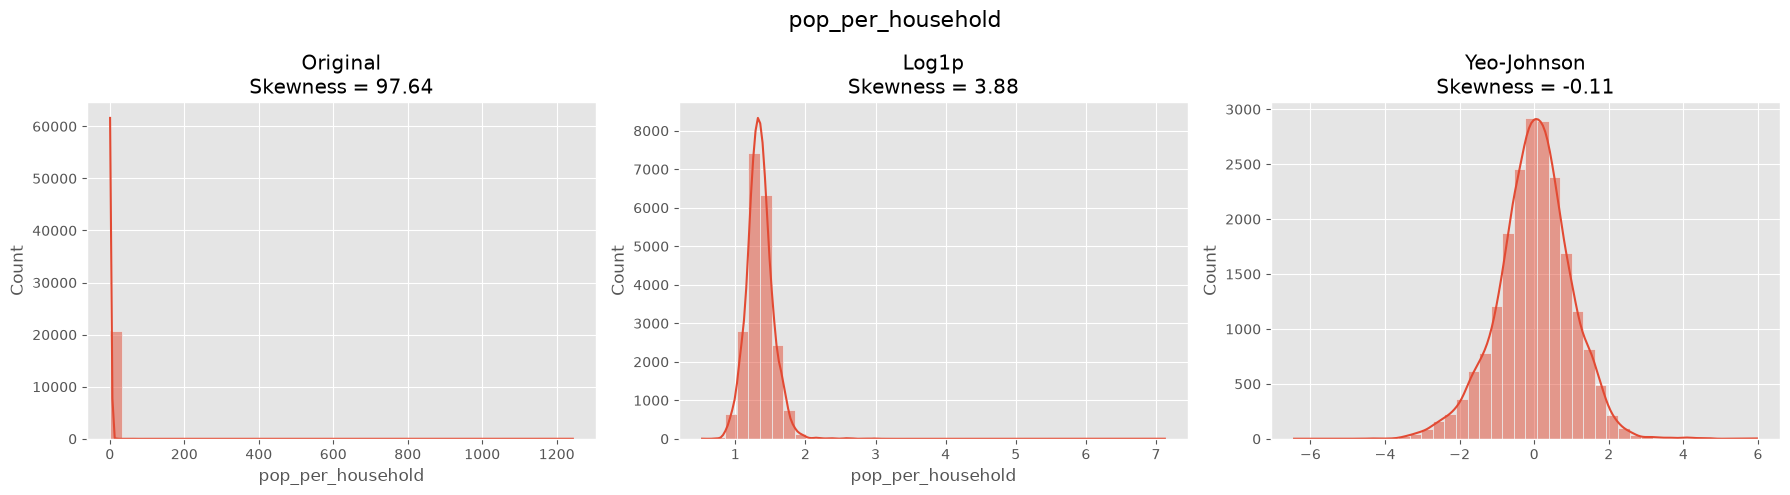

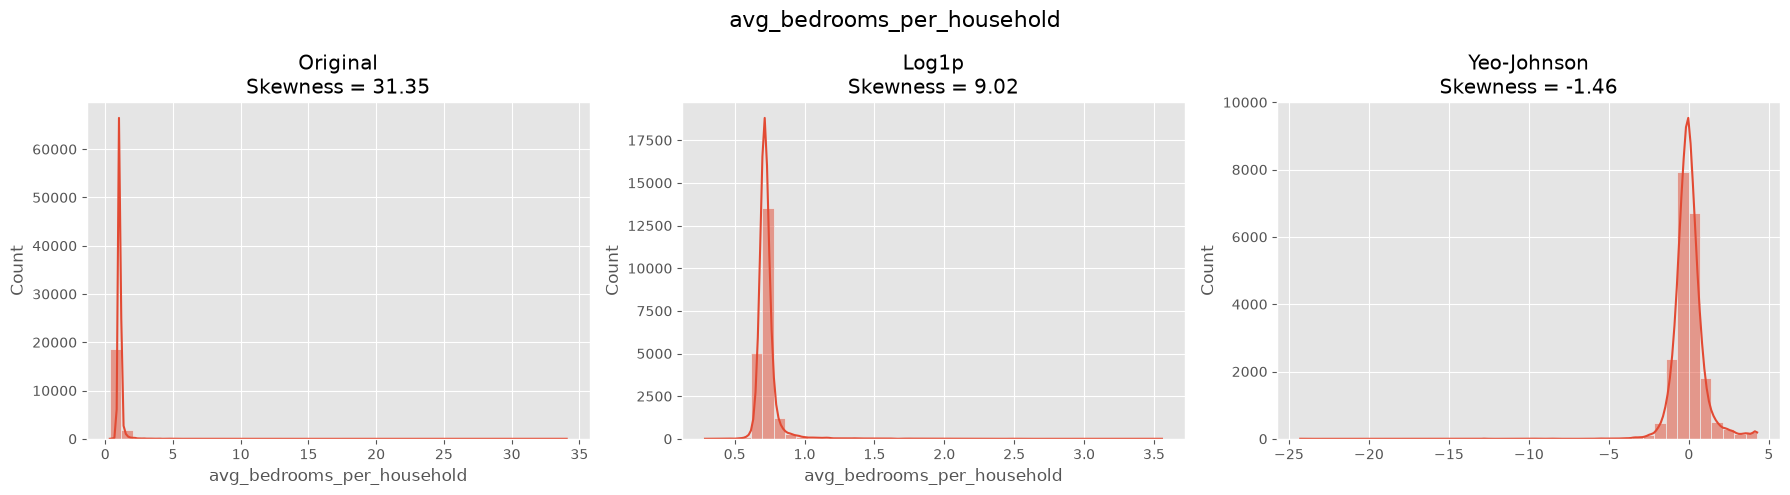

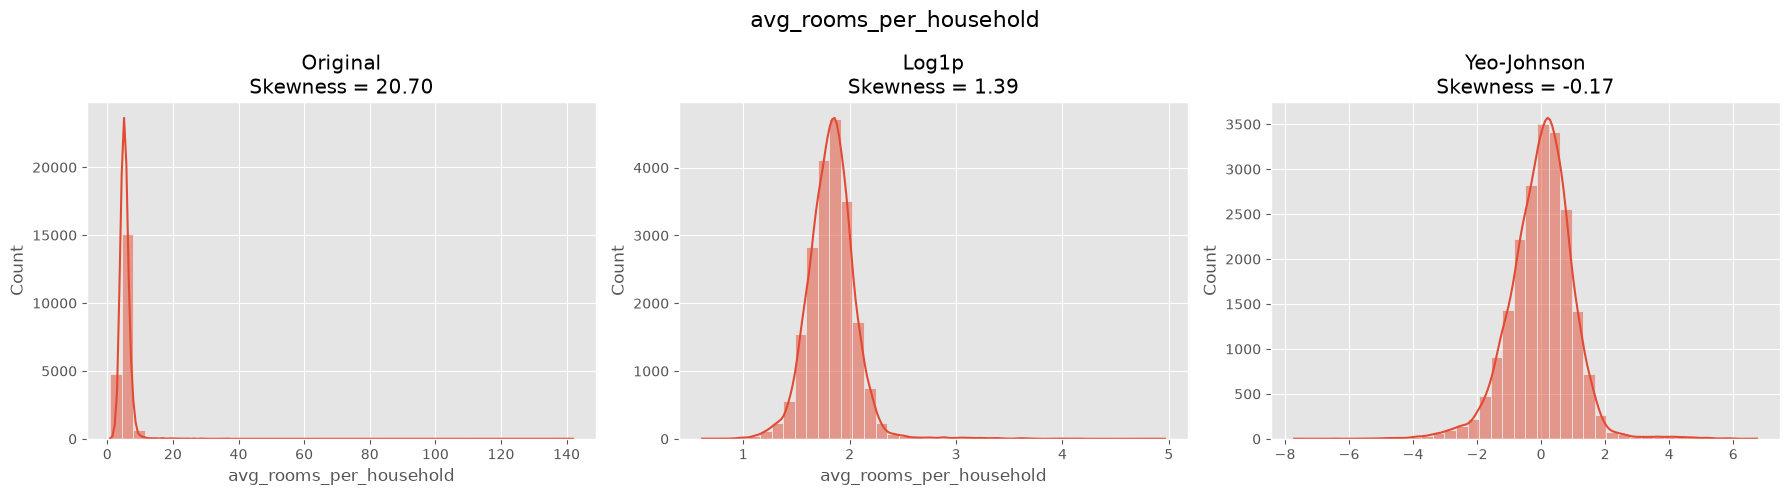

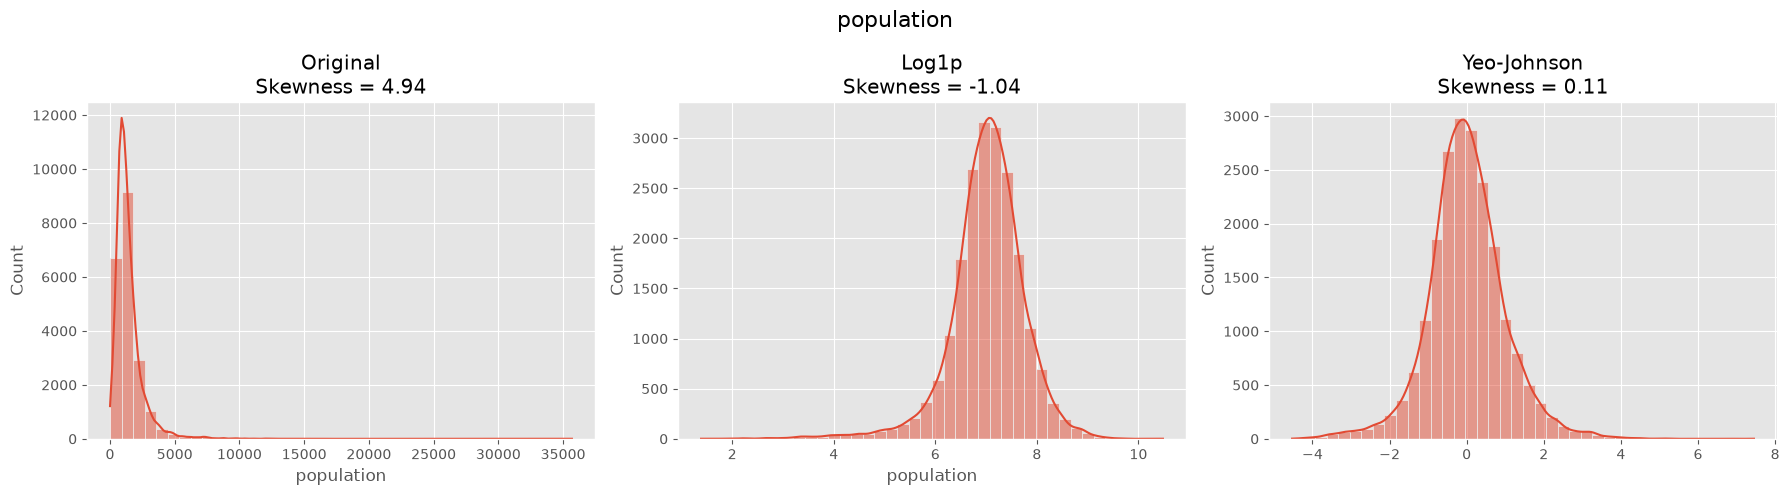

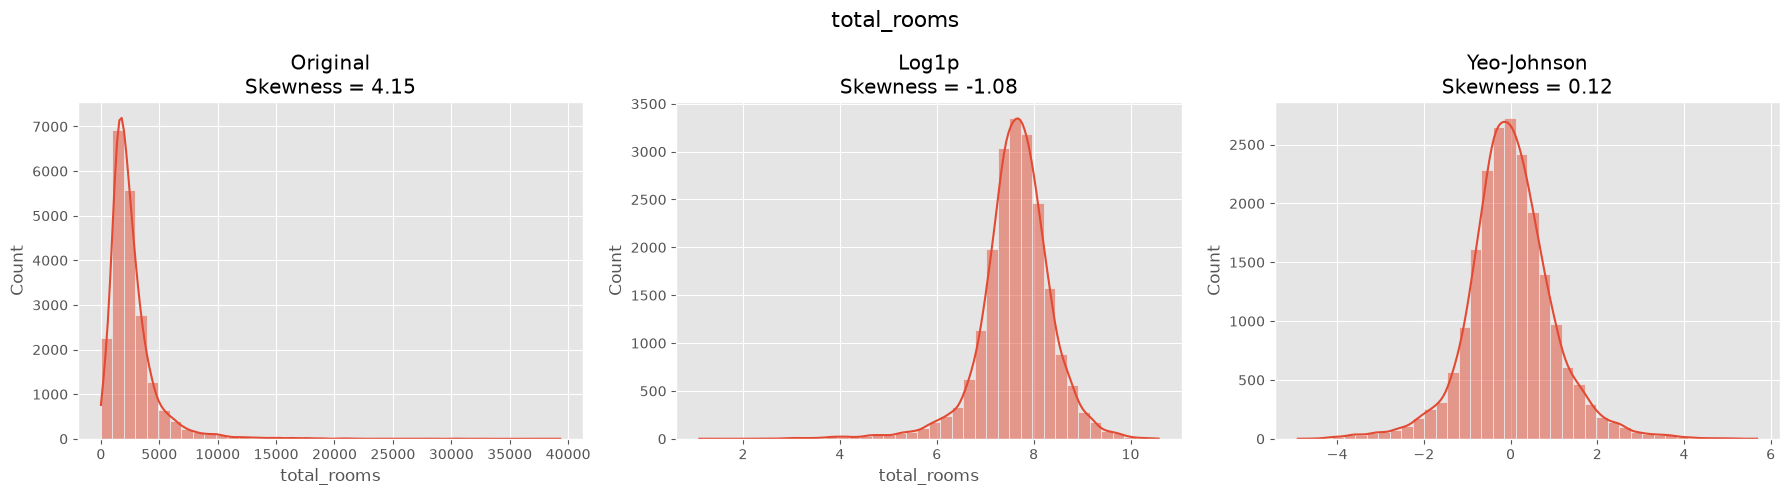

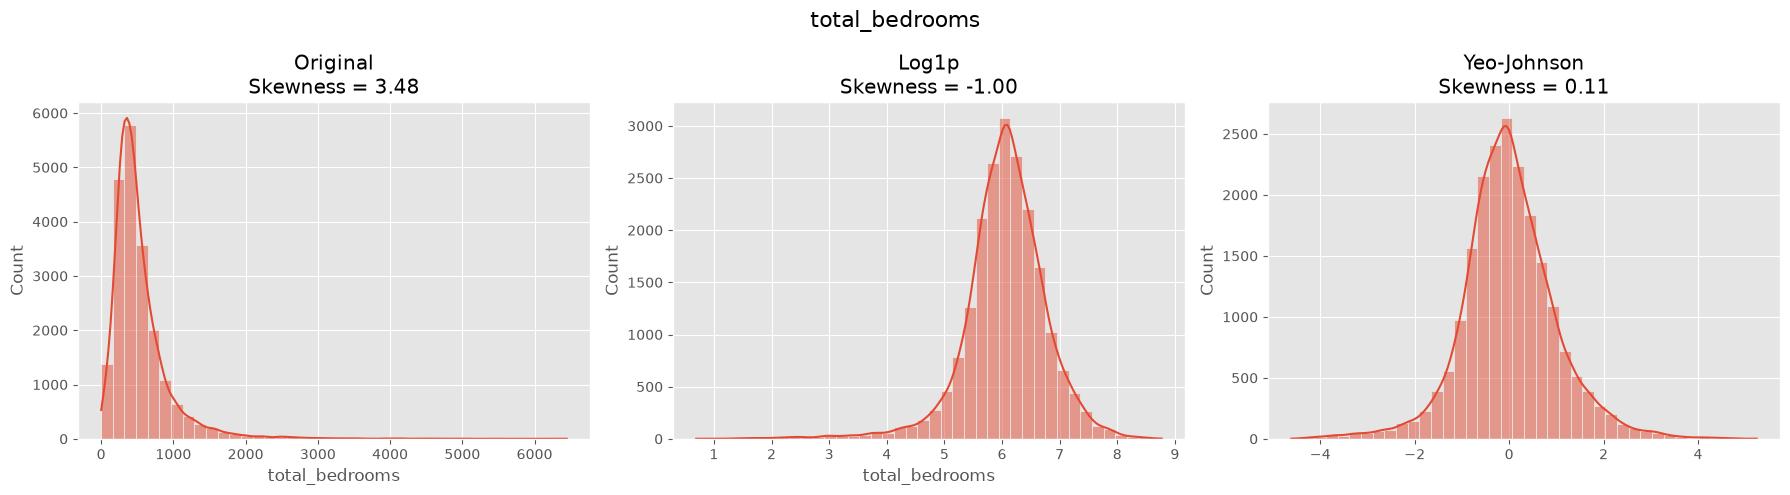

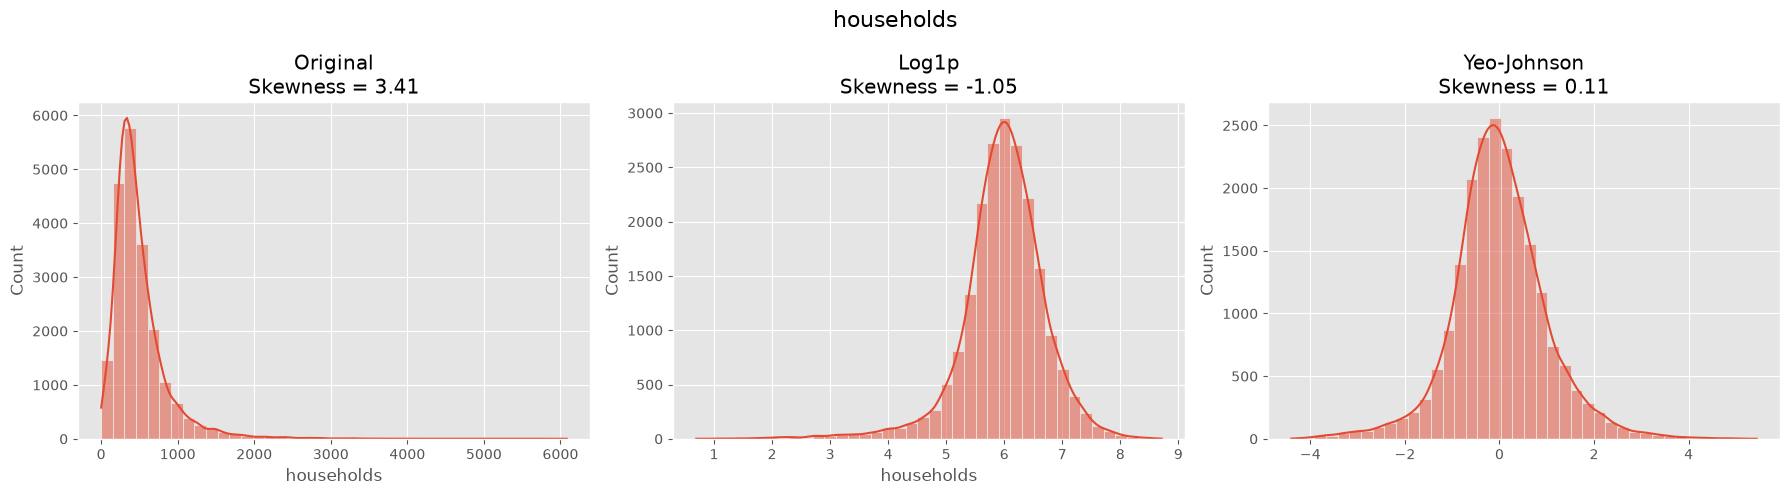


Transformation Comparison:
                   Feature  Original       Log     Power
         pop_per_household 97.639561  3.879679 -0.106888
avg_bedrooms_per_household 31.351784  9.024855 -1.463029
   avg_rooms_per_household 20.697869  1.390761 -0.170146
                population  4.935858 -1.044087  0.110641
               total_rooms  4.147343 -1.075533  0.121378
            total_bedrooms  3.481141 -0.998768  0.107957
                households  3.410438 -1.051607  0.109520


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer


def compare_transformations(data, top_n=7):
    skewness = (
        data.select_dtypes(include=np.number)
        .skew()
        .sort_values(ascending=False)
    )

    skewed_cols = skewness[skewness > 1].head(top_n).index

    print("Top skewed columns:")
    print(skewness[skewed_cols])

    results = []
    for col in skewed_cols:

        original = data[col]
        log = np.log1p(original)
        pt = PowerTransformer(method="yeo-johnson")
        power = pt.fit_transform(data[[col]]).ravel()
        results.append({
            "Feature": col,
            "Original": original.skew(),
            "Log": log.skew(),
            "Power": pd.Series(power).skew()
        })
        plt.figure(figsize=(18, 5))
        plt.subplot(1, 3, 1)
        sns.histplot(original, kde=True, bins=40)
        plt.title(f"Original\nSkewness = {original.skew():.2f}")
        plt.subplot(1, 3, 2)
        sns.histplot(log, kde=True, bins=40)
        plt.title(f"Log1p\nSkewness = {log.skew():.2f}")
        plt.subplot(1, 3, 3)
        sns.histplot(power, kde=True, bins=40)
        plt.title(f"Yeo-Johnson\nSkewness = {pd.Series(power).skew():.2f}")
        plt.suptitle(col, fontsize=16)
        plt.tight_layout()
        plt.show()
    return pd.DataFrame(results)
comparison = compare_transformations(df, top_n=7)

print("\nTransformation Comparison:")
print(comparison.to_string(index=False))

In [23]:
# for safest approach is to make apply power transformation after splitting 
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
X=df.drop("median_house_value", axis=1)
y=df["median_house_value"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Shape of x_train set:", X_train.shape)
print("Shape of x_test set:", X_test.shape)
print("Shape of y_train set:", y_train.shape)
print("Shape of y_test set:", y_test.shape)


Shape of x_train set: (16512, 12)
Shape of x_test set: (4128, 12)
Shape of y_train set: (16512,)
Shape of y_test set: (4128,)


In [24]:
cols_to_transform=[
    col for col in feature_skewness.index if feature_skewness[col] > 1  
]
cols_to_transform.remove("median_income")

In [25]:
cols_to_transform

['pop_per_household',
 'avg_bedrooms_per_household',
 'avg_rooms_per_household',
 'population',
 'total_rooms',
 'total_bedrooms',
 'households']

In [26]:
pt = PowerTransformer(method="yeo-johnson")
X_train[cols_to_transform] = pt.fit_transform(X_train[cols_to_transform])
X_test[cols_to_transform] = pt.transform(X_test[cols_to_transform])

In [27]:
for col in X_train.select_dtypes(include=np.number).columns:
    Q3 = X_train[col].quantile(0.75)
    Q1 = X_train[col].quantile(0.25)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    print(f"Number of outliers in {col}: {outliers.shape[0]} , {(outliers.shape[0] / X_train.shape[0]) * 100:.2f}%")
   

Number of outliers in longitude: 0 , 0.00%
Number of outliers in latitude: 0 , 0.00%
Number of outliers in housing_median_age: 0 , 0.00%
Number of outliers in total_rooms: 751 , 4.55%
Number of outliers in total_bedrooms: 669 , 4.05%
Number of outliers in population: 680 , 4.12%
Number of outliers in households: 694 , 4.20%
Number of outliers in median_income: 529 , 3.20%
Number of outliers in pop_per_household: 403 , 2.44%
Number of outliers in avg_rooms_per_household: 487 , 2.95%
Number of outliers in avg_bedrooms_per_household: 1034 , 6.26%


In [28]:
# clipping the outliers in the training set using IQR method
for col in X_train.select_dtypes(include=np.number).columns:
    Q3 = X_train[col].quantile(0.75)
    Q1 = X_train[col].quantile(0.25)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

numeric_cols = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
    'pop_per_household',
    'avg_rooms_per_household',
    'avg_bedrooms_per_household'
]
categorical_cols = [
    'ocean_proximity'
]

processor_all = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numeric_cols),
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline_all = Pipeline(
    steps=[
        ('preprocessor', processor_all),
        ('regressor', LinearRegression())
    ]
)
pipeline_all.fit(X_train, y_train)

y_pred_all = pipeline_all.predict(X_test)
mae_all = mean_absolute_error(y_test, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
r2_all = r2_score(y_test, y_pred_all)
print("Pipeline 1 - All Features")
print(f"MAE  : {mae_all:.2f}")
print(f"RMSE : {rmse_all:.2f}")
print(f"R²   : {r2_all:.4f}")


Pipeline 1 - All Features
MAE  : 49084.31
RMSE : 67016.28
R²   : 0.6573


In [30]:
numeric_cols_reduced = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'median_income',
    'pop_per_household',
    'avg_rooms_per_household',
    'avg_bedrooms_per_household'
]

categorical_cols = [
    'ocean_proximity'
]


processor_reduced = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numeric_cols_reduced),
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


pipeline_reduced = Pipeline(
    steps=[
        ('preprocessor', processor_reduced),
        ('regressor', LinearRegression())
    ]
)
X_train_reduced = X_train.drop(
    ['population', 'households'],
    axis=1
)

X_test_reduced = X_test.drop(
    ['population', 'households'],
    axis=1
)
pipeline_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = pipeline_reduced.predict(X_test_reduced)
mae_reduced = mean_absolute_error(y_test, y_pred_reduced)
rmse_reduced = np.sqrt(
    mean_squared_error(y_test, y_pred_reduced)
)
r2_reduced = r2_score(y_test, y_pred_reduced)
print("Pipeline 2 - Without Population & Households")
print(f"MAE  : {mae_reduced:.2f}")
print(f"RMSE : {rmse_reduced:.2f}")
print(f"R²   : {r2_reduced:.4f}")

Pipeline 2 - Without Population & Households
MAE  : 48943.29
RMSE : 66780.03
R²   : 0.6597


In [31]:
from sklearn.ensemble import HistGradientBoostingRegressor

pipeline_hgb = Pipeline(
    steps=[
        ('preprocessor', processor_all),
        ('regressor', HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)
pipeline_hgb.fit(X_train, y_train)
y_pred_hgb = pipeline_hgb.predict(X_test)
mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
r2_hgb = r2_score(y_test, y_pred_hgb)
print("HistGradientBoosting")
print(f"MAE  : {mae_hgb:.2f}")
print(f"RMSE : {rmse_hgb:.2f}")
print(f"R²   : {r2_hgb:.4f}")

HistGradientBoosting
MAE  : 29865.06
RMSE : 45236.59
R²   : 0.8438


In [32]:
from sklearn.ensemble import RandomForestRegressor
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', processor_all),
        ('regressor', RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)
r2_rf = r2_score(y_test, y_pred_rf)
print("Pipeline - Random Forest")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Pipeline - Random Forest
MAE  : 32403.26
RMSE : 50023.52
R²   : 0.8090


In [33]:
result_df=pd.DataFrame({
    "Model": [
        "Linear Regression - All Features",
        "Linear Regression - Without Pop & Households",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "MAE": [
        mae_all,
        mae_reduced,
        mae_rf,
        mae_hgb
    ],
    "RMSE": [
        rmse_all,
        rmse_reduced,
        rmse_rf,
        rmse_hgb
    ],
    "R²": [
        r2_all,
        r2_reduced,
        r2_rf,
        r2_hgb
    ]
})
result_df

,Model,MAE,RMSE,R²
0,Linear Regression - All Features,49084.310694,67016.281920,0.657269
1,Linear Regression - Without Pop & Households,48943.286943,66780.026197,0.659681
2,Random Forest,32403.262741,50023.523935,0.809040
3,HistGradientBoosting,29865.055629,45236.593042,0.843839


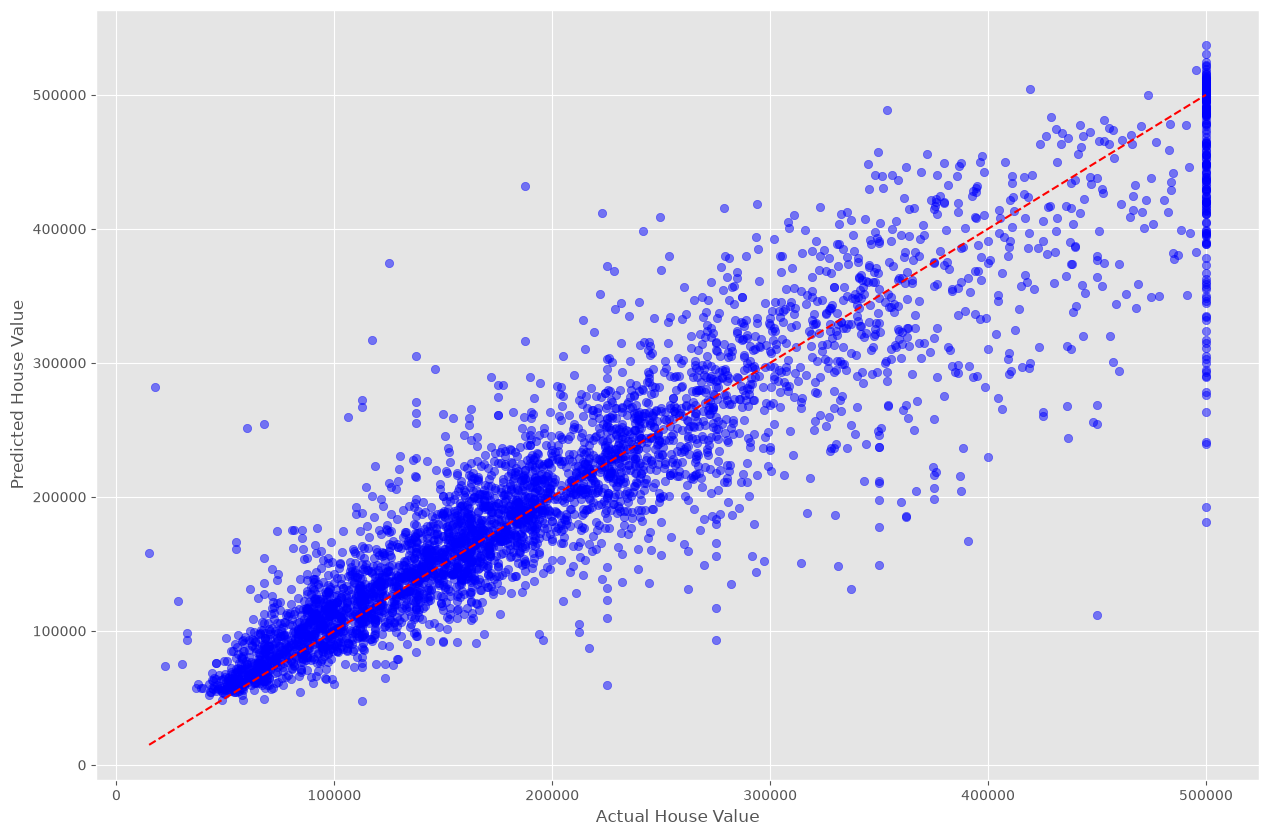

In [35]:
plt.figure(figsize=(15,10))
plt.scatter(y_test , y_pred_hgb , color="blue", alpha=0.5)
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],color="red",linestyle="--")

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.show()
